# Method B: readouts gathered at each hex's right corner, all horizontal

`src/single_ancilla/method_b/method_b.py`, step by step (method B of hexes.pdf). One ancilla sits halfway along every
edge. A step measures one colour of edges from the hexes of the previous colour: each checked edge's own ancilla
(the syndrome) picks up the parity of the two data next to it, then the readout pair gathers at the edge's end u,
always some hex's right corner. How depends on which corner of the checking hex u is:

| u's corner | example (red hex, d = 2) | what moves | readout pair |
|---|---|---|---|
| top left | D1-D0 | syndrome A13 swaps into D0 | D0 + A0, the top edge |
| right | D12-D13 | syndrome A5 swaps into D13 | D13 + A15, sticking out to the right |
| bottom left | D14-D2 | reference A2 swaps into D2 | A12 + D2, the bottom edge |

Every readout pair is horizontal, so one charge sensor just left of each right corner reads every step.
`make experiments` saves the same drawings as PNGs in `results/single_ancilla/method_b/`.

In [1]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

from IPython.display import SVG, display

# the repo root, whether the kernel starts there or in notebooks/single_ancilla/
ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / "src" / "single_ancilla").is_dir())
sys.path[:0] = [str(ROOT / "src" / "single_ancilla" / "method_b"), str(ROOT / "src" / "single_ancilla")]

import shared
from floquet import hex_centers, period, qubits, torus
from method_b import layers
from method_a import qubit_kinds

In [2]:
# The Makefile's DRAW_DISTANCE. 1 is 12 data qubits and 18 ancillas; 2 is 48 and 72.
DISTANCE = 1
NUMBERS = True  # label every qubit: Di data qubit i, Ak the ancilla of edge k
AWAY = False  # where the sensor squares go: just left of the corner
names = ["blue", "red", "green"]  # colour 0, 1, 2, as plots.py draws them

## The checks of each step

Step r measures XX (even r) or ZZ (odd r) on the colour r % 3 edges, from the hexes of colour r % 3 - 1, in the
`bX rZ gX bZ rX gZ` schedule of `floquet.py`. `shared.checks` gives each edge v-u (clockwise around its hex), its
own ancilla a, the next ancilla s clockwise from u and u's outward ancilla o; the method picks which is syndrome
and which is reference. The first three checks of each step:

In [3]:
kinds = list(qubit_kinds(DISTANCE))
n_data = len(qubits(DISTANCE))
label = [f"D{i}" if i < n_data else f"A{i - n_data}" for i in range(len(kinds))]
q2i = {q: i for i, q in enumerate(kinds)}
corner_name = {0: "right", 2: "bottom-left", 4: "top-left"}
for r in range(6):
    checks = shared.checks(DISTANCE, r % 3)
    print(f"step {r}: {'XZ'[r % 2] * 2} on {names[r % 3]} edges, from the {names[(r % 3 - 1) % 3]} hexes,"
          f" {len(checks)} checks")
    for check in checks[:3]:
        _, u, v, *_, corner = check
        _, syndrome, reference = shared.gates(layers, "XZ"[r % 2], check, q2i)
        print(f"    {label[q2i[v]]}-{label[q2i[u]]}: syndrome {label[syndrome]}, reference {label[reference]},"
              f" read out at {label[q2i[u]]}, a {corner_name[corner]} corner")

step 0: XX on blue edges, from the green hexes, 6 checks
    D6-D0: syndrome A0, reference A14, read out at D0, a bottom-left corner
    D5-D4: syndrome A1, reference A12, read out at D4, a top-left corner
    D1-D2: syndrome A2, reference A6, read out at D2, a right corner
step 1: ZZ on red edges, from the blue hexes, 6 checks
    D1-D7: syndrome A9, reference A5, read out at D7, a bottom-left corner
    D6-D11: syndrome A10, reference A3, read out at D11, a top-left corner
    D8-D9: syndrome A11, reference A15, read out at D9, a right corner
step 2: XX on green edges, from the red hexes, 6 checks
    D5-D11: syndrome A3, reference A17, read out at D11, a bottom-left corner
    D10-D9: syndrome A4, reference A15, read out at D9, a top-left corner
    D6-D7: syndrome A5, reference A9, read out at D7, a right corner
step 3: ZZ on blue edges, from the green hexes, 6 checks
    D6-D0: syndrome A0, reference A14, read out at D0, a bottom-left corner
    D5-D4: syndrome A1, reference A12, 

## The six steps

Labels follow the states: a SWAP moves a qubit's label with it, so `Dk` is wherever data qubit k is at that
tick. Syndromes are white, references grey, data filled. Every step resets, runs the two controlled-Pauli gates
(an H too on XX steps), swaps, reads out by MZZ and swaps back. Pairs that wrap around the torus are drawn as
two short stubs at the picture's edges. The squares are the charge sensors, one per readout.

step 0: XX on blue edges


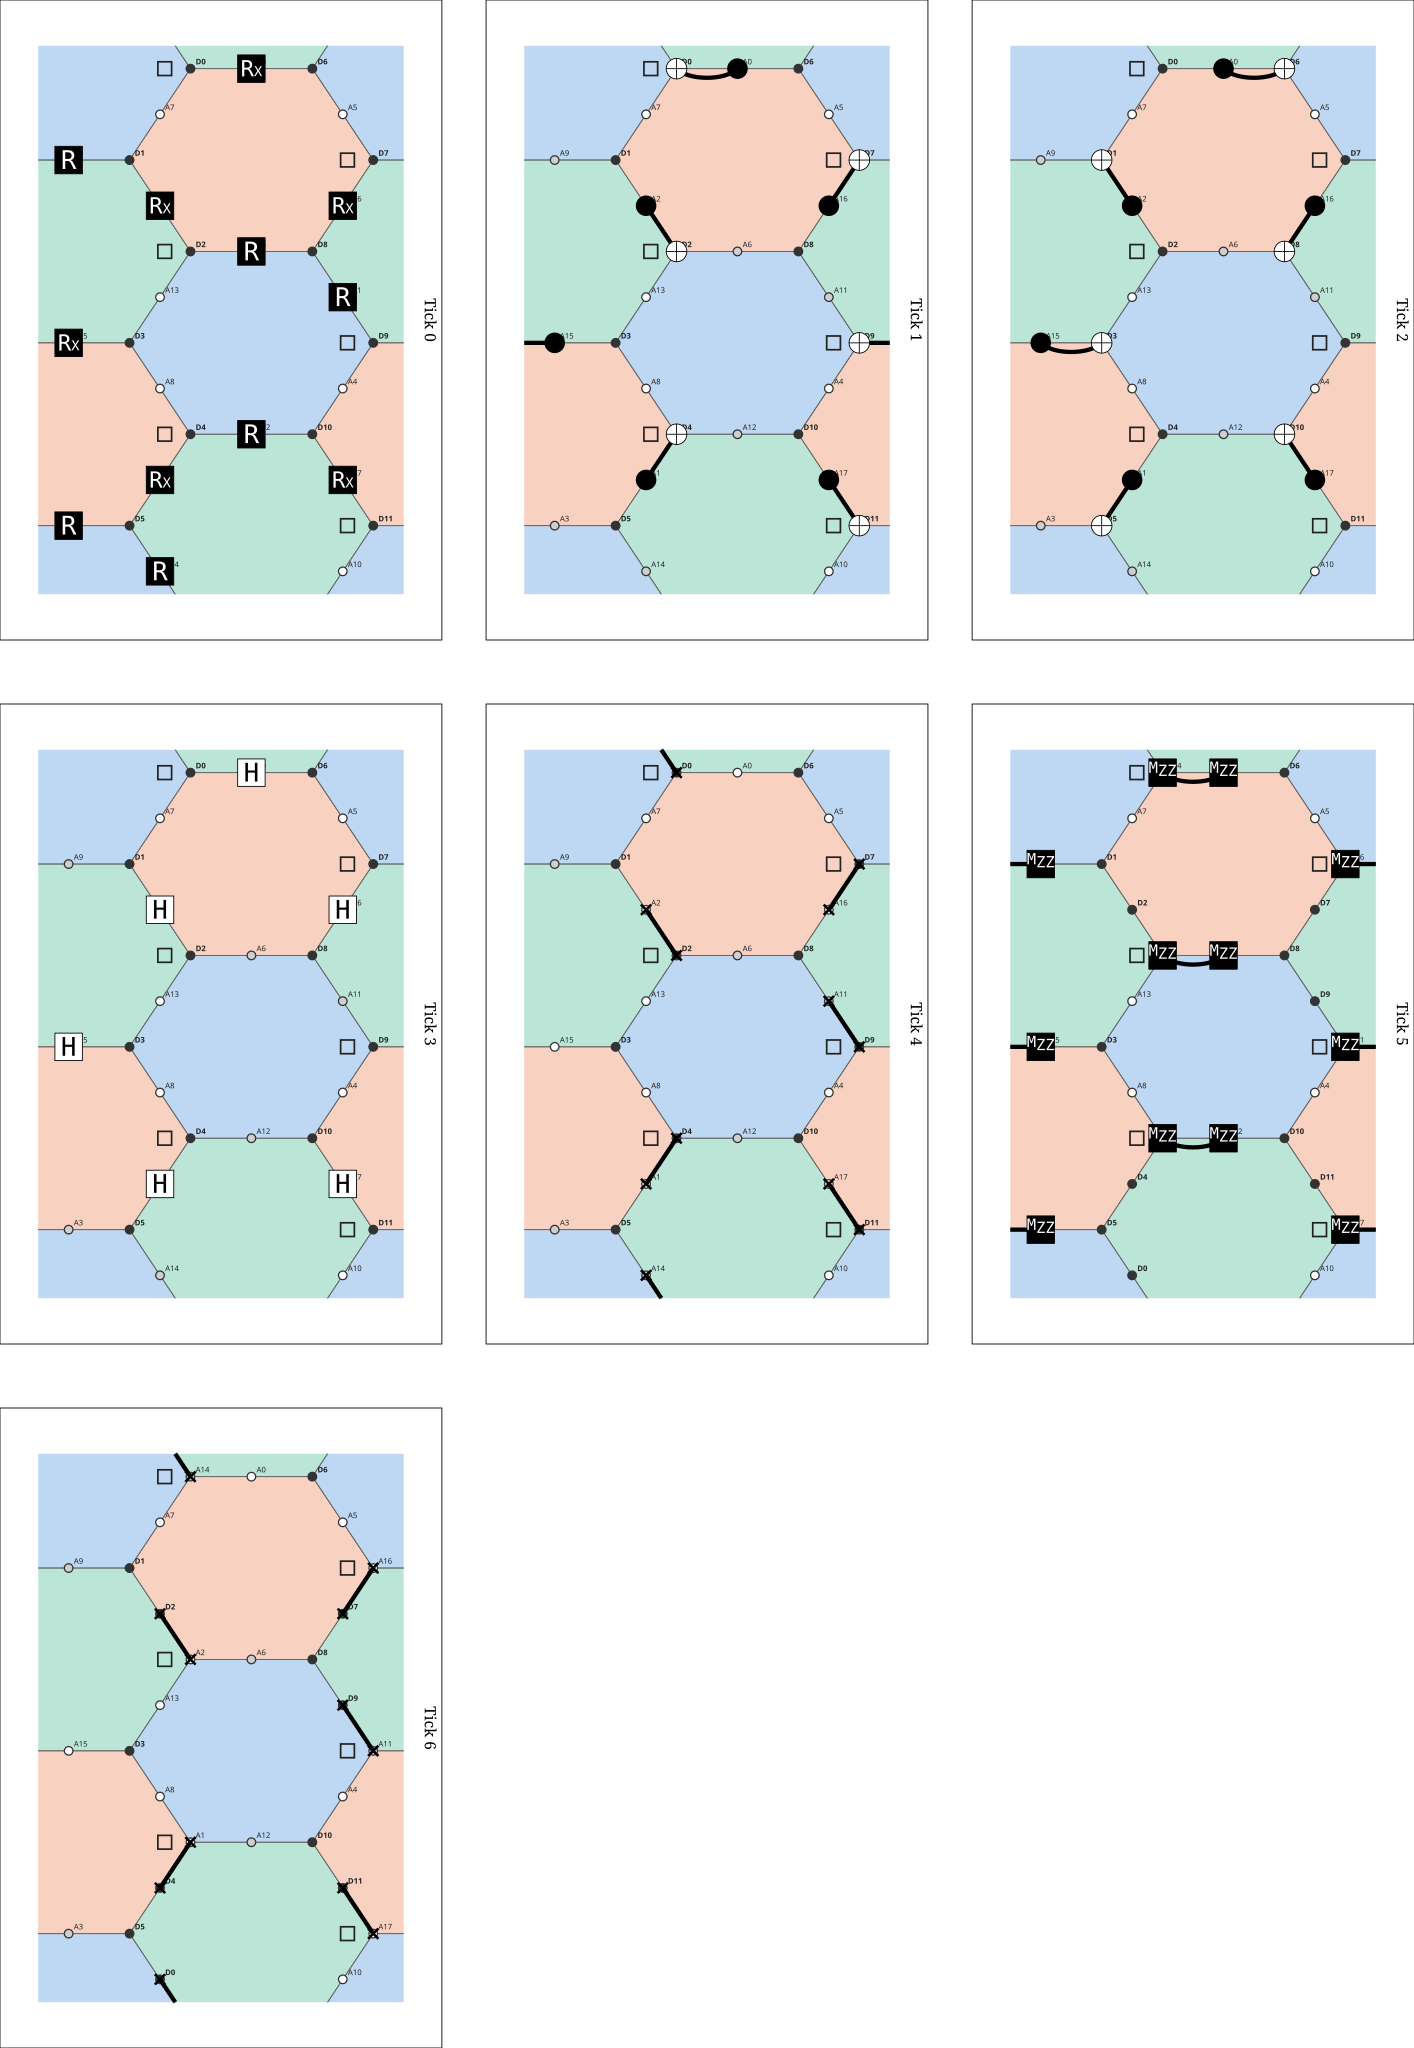

step 1: ZZ on red edges


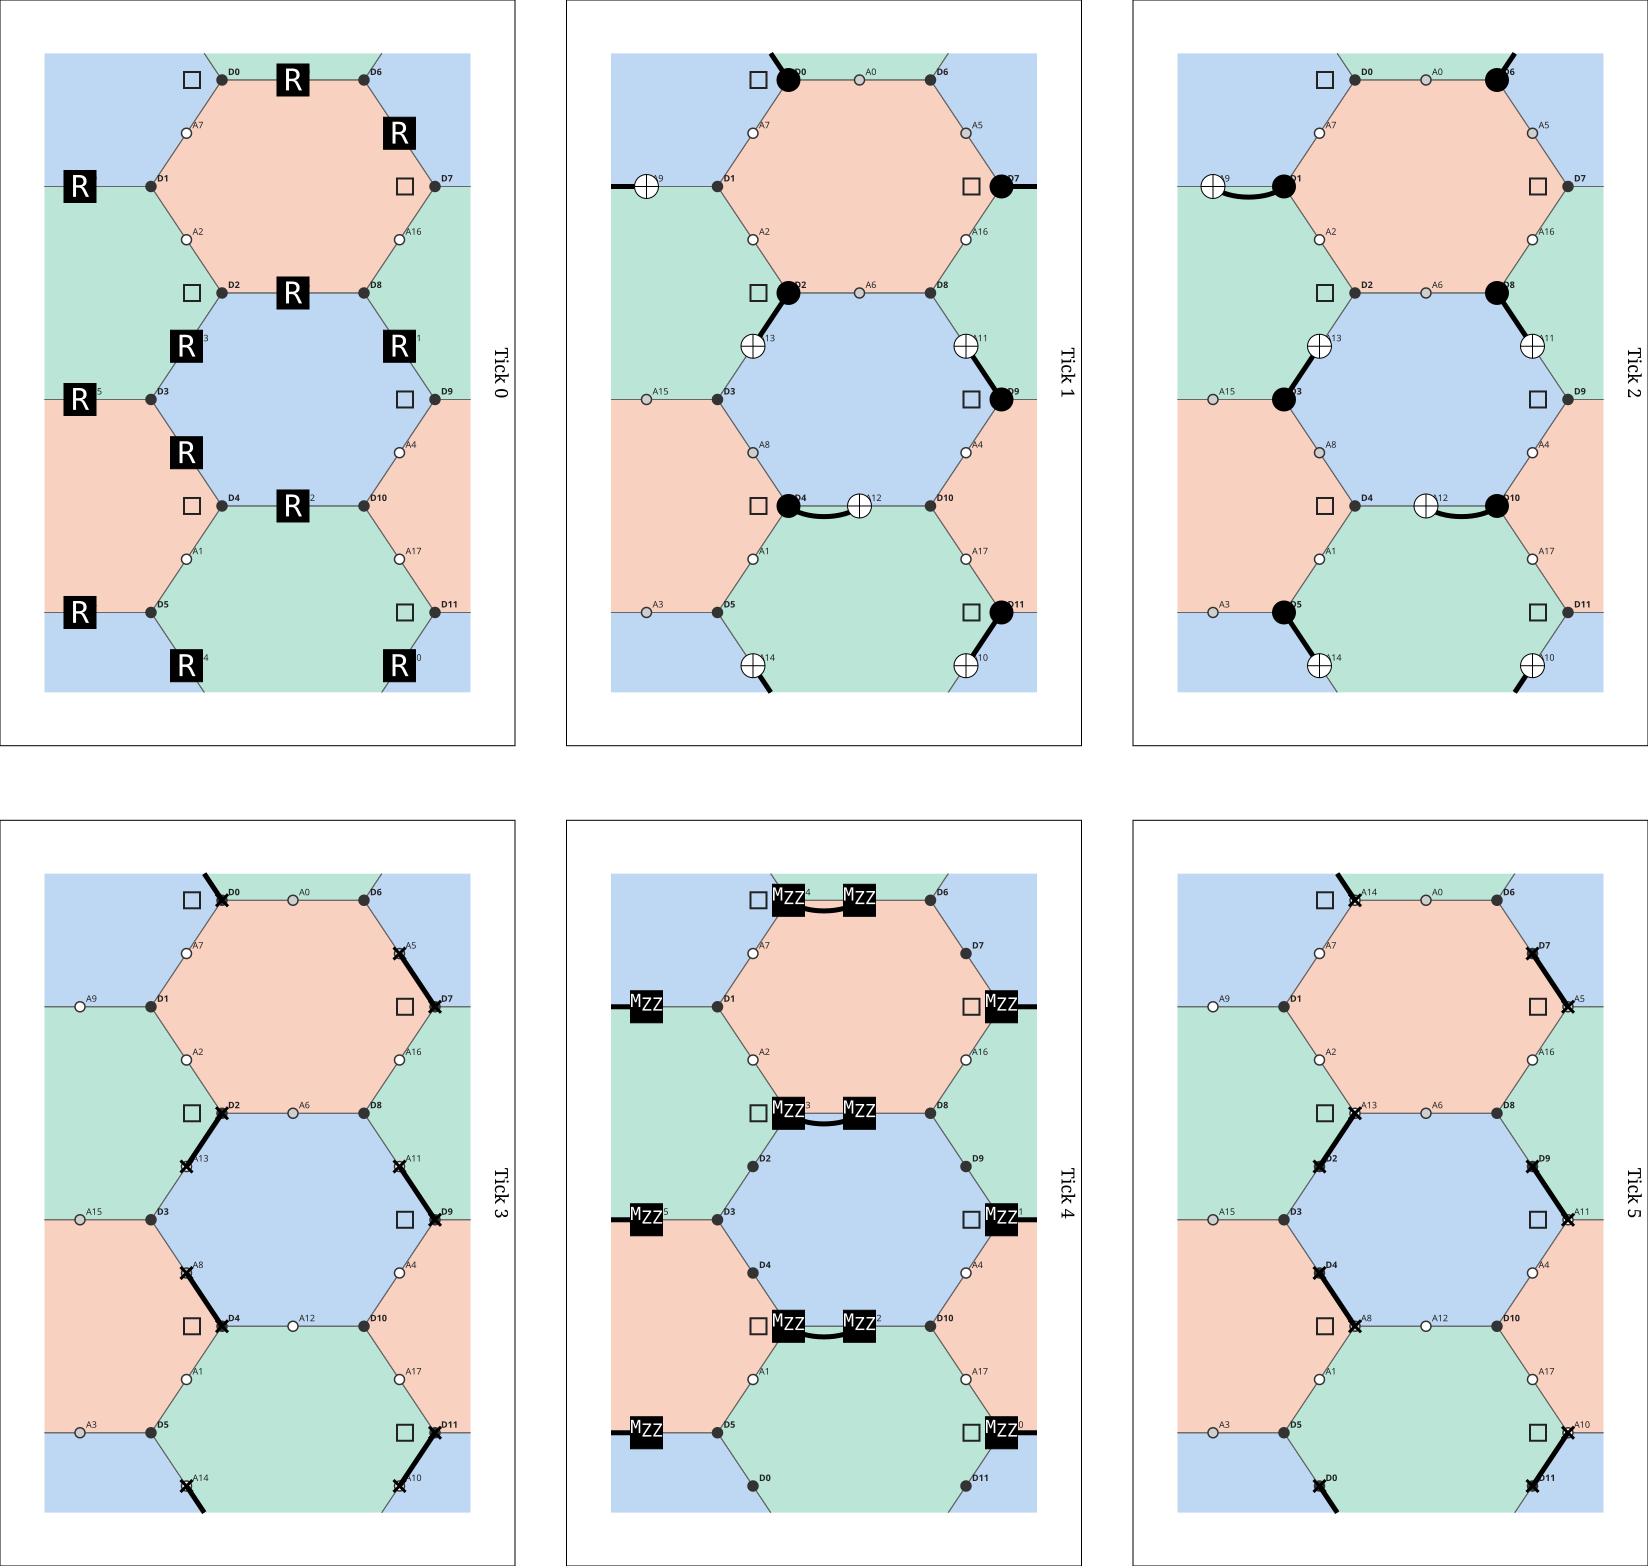

step 2: XX on green edges


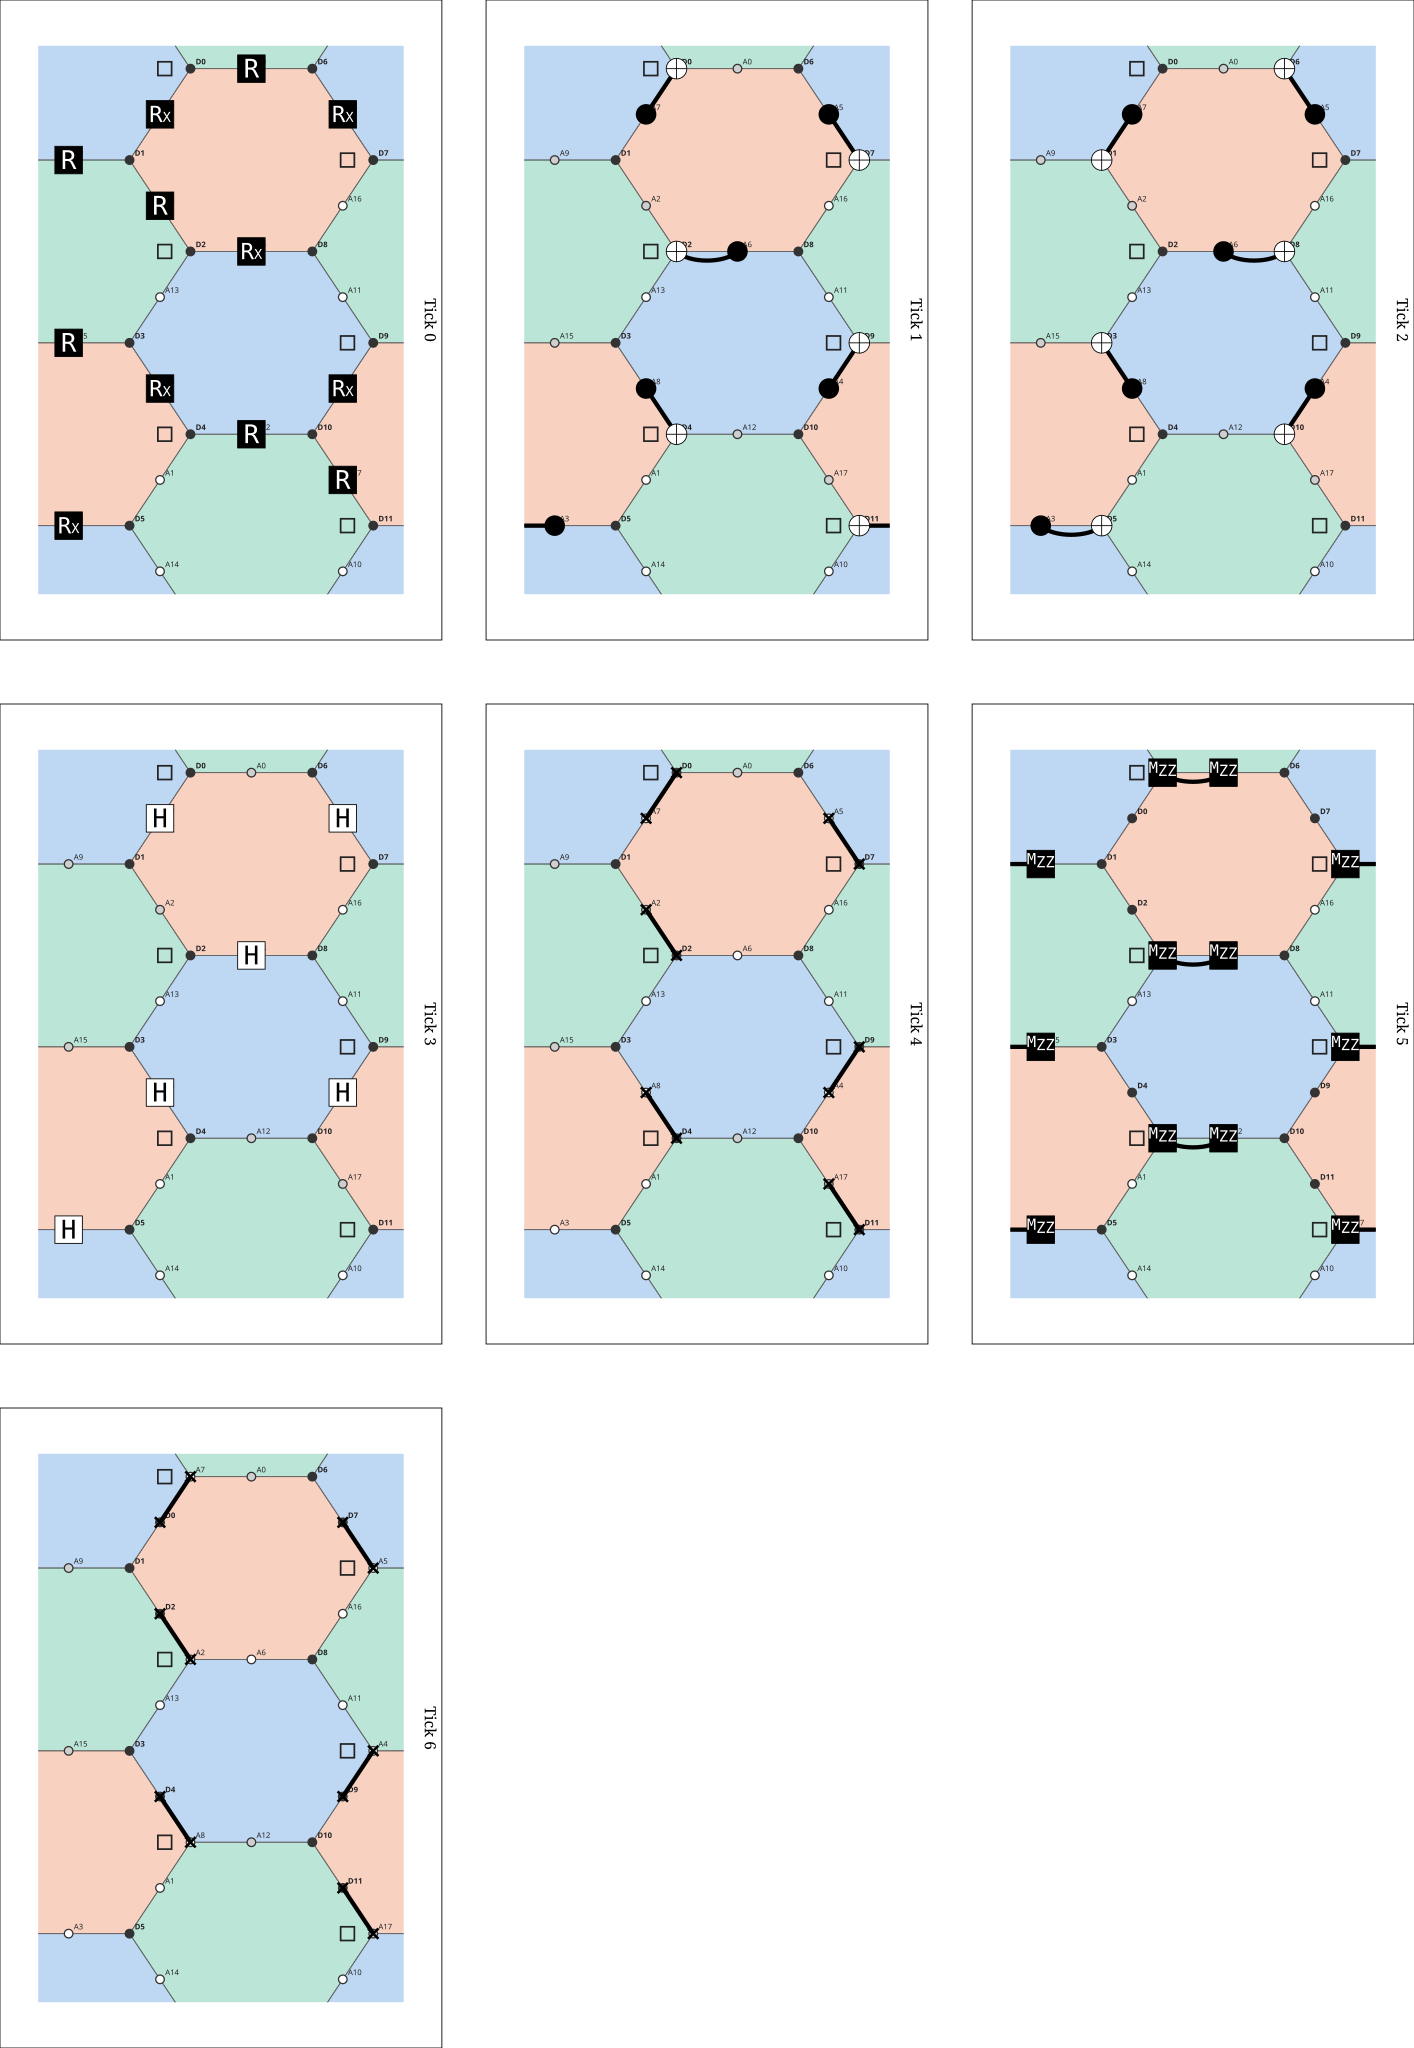

step 3: ZZ on blue edges


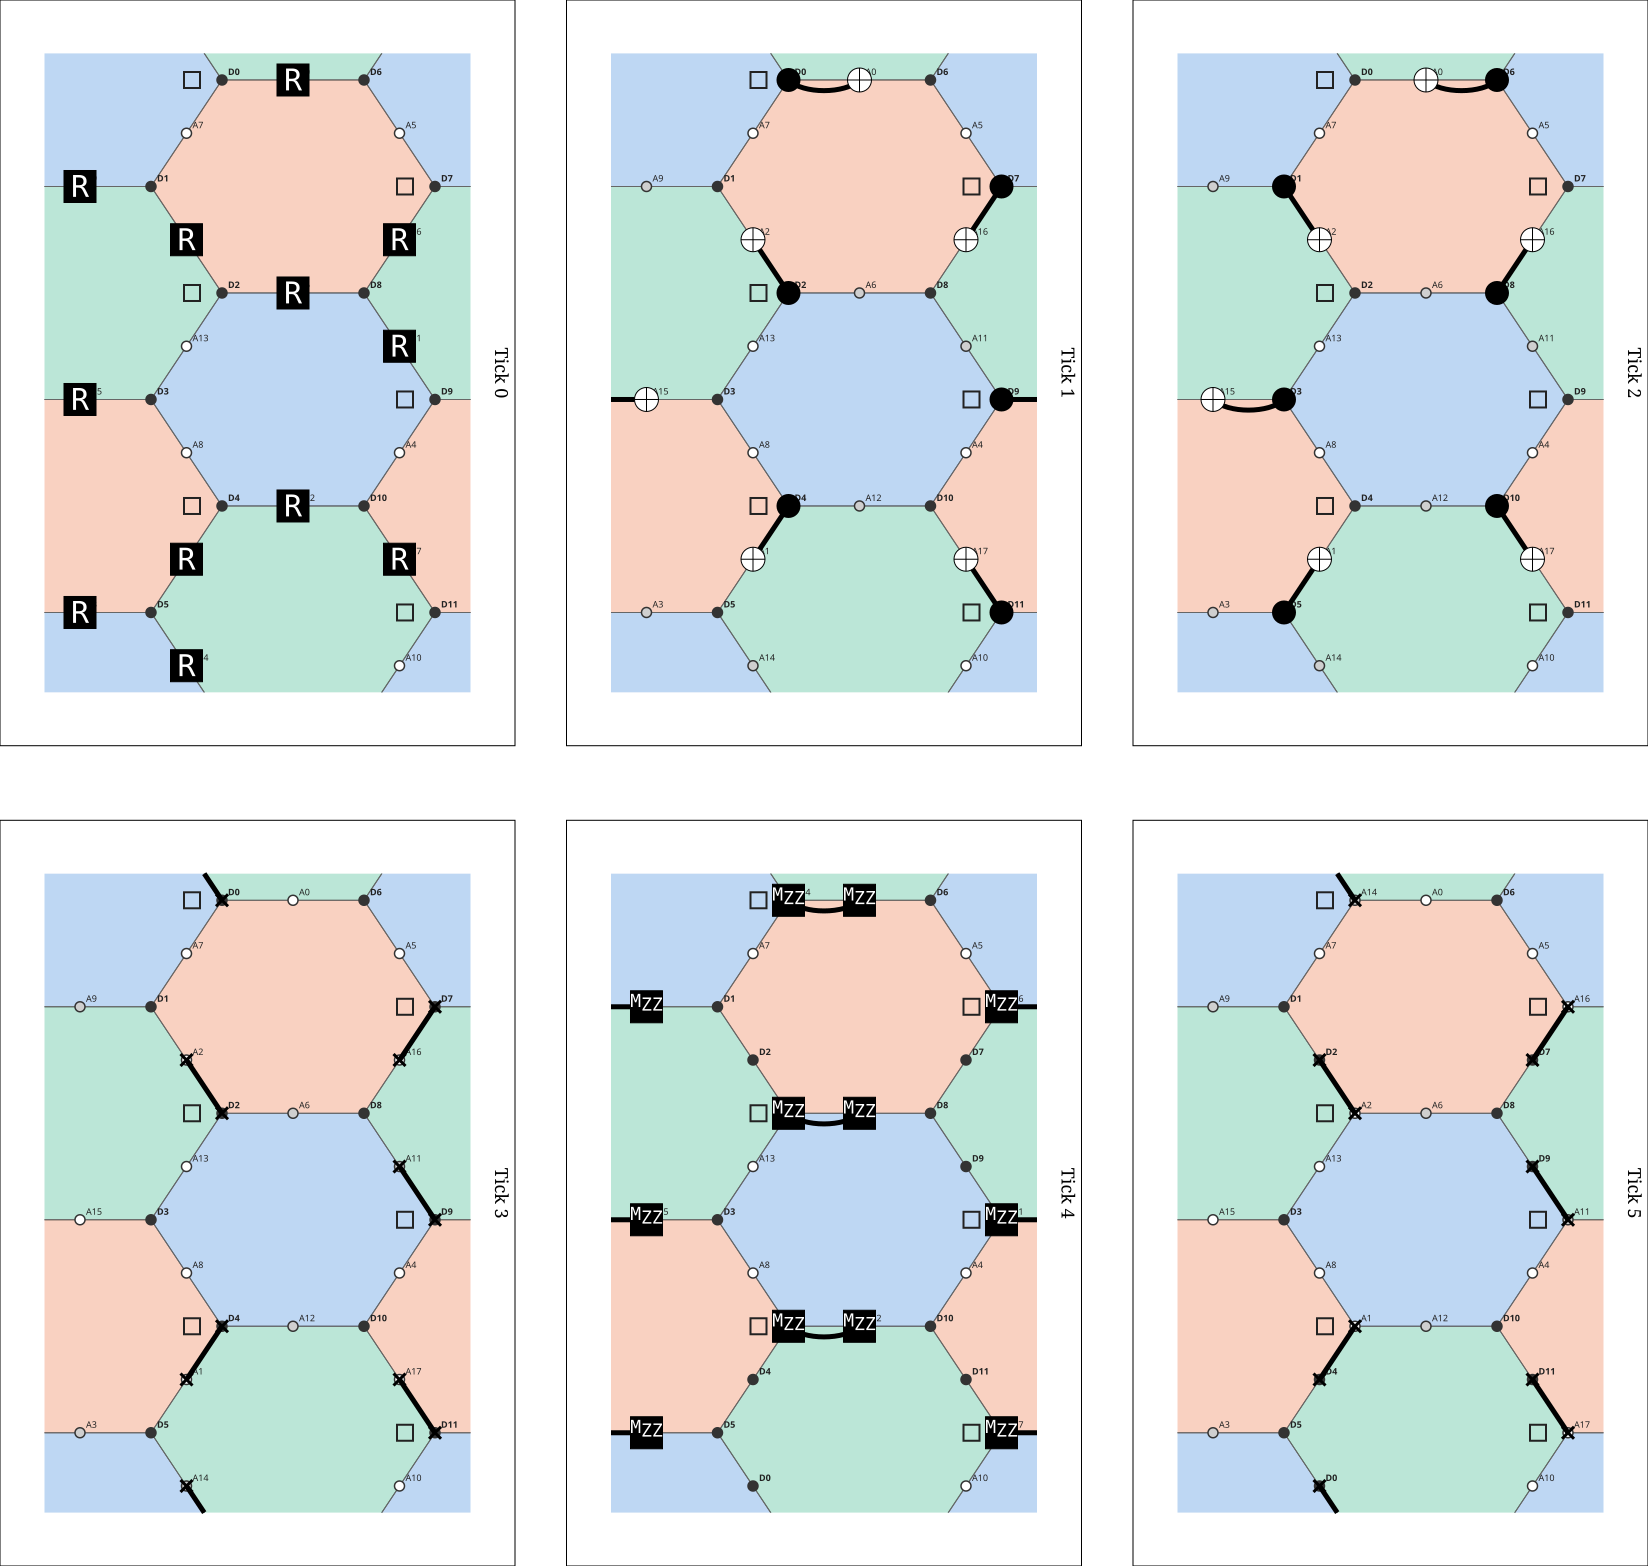

step 4: XX on red edges


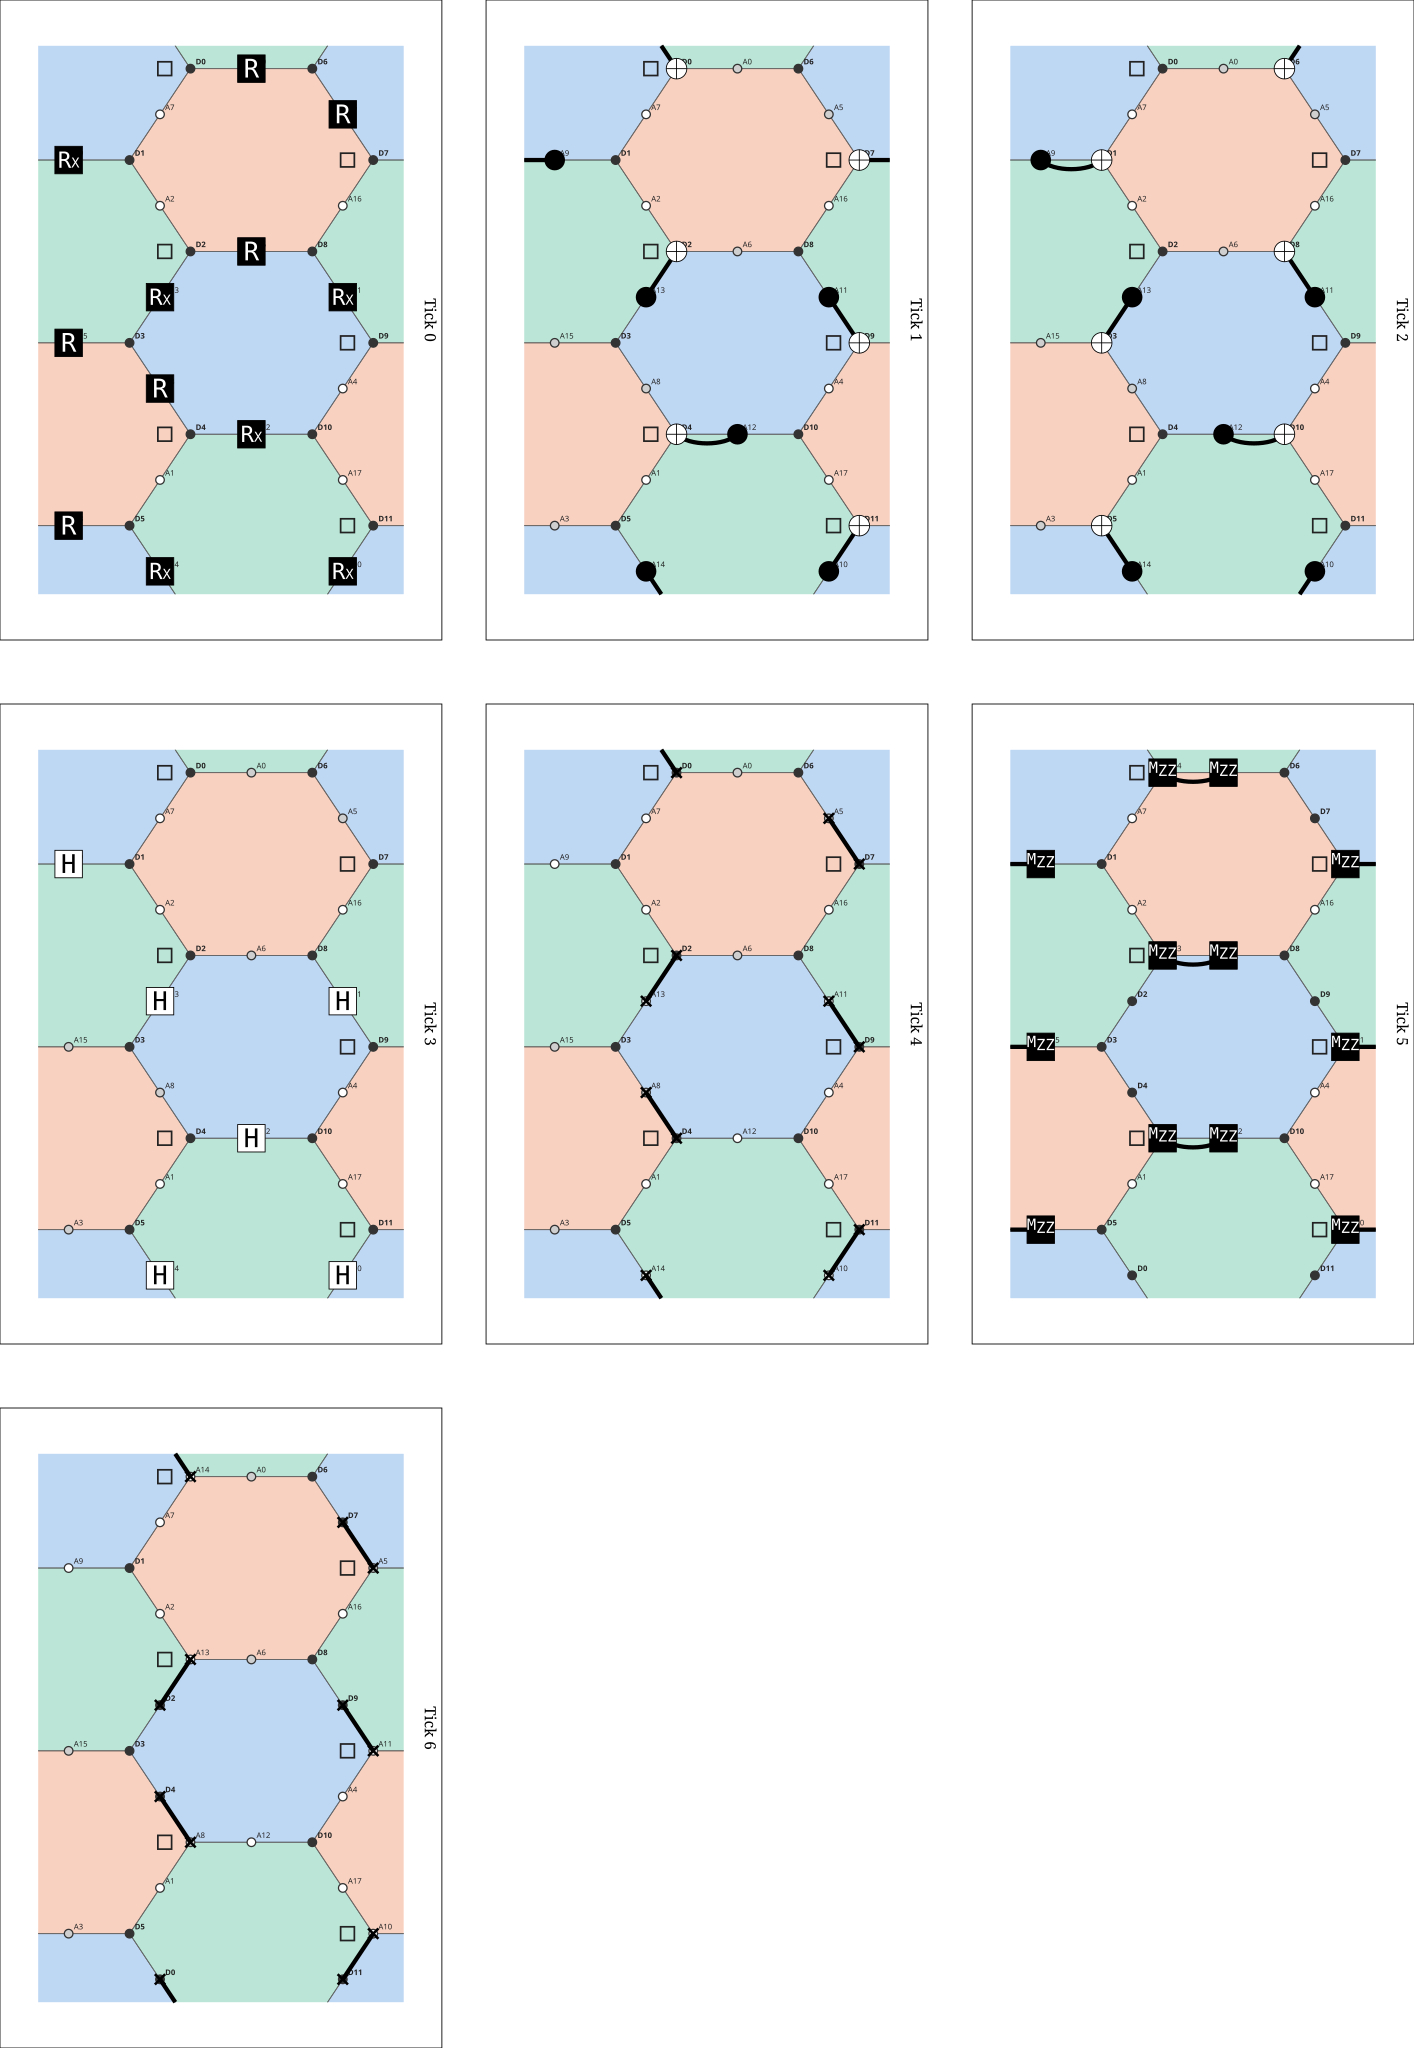

step 5: ZZ on green edges


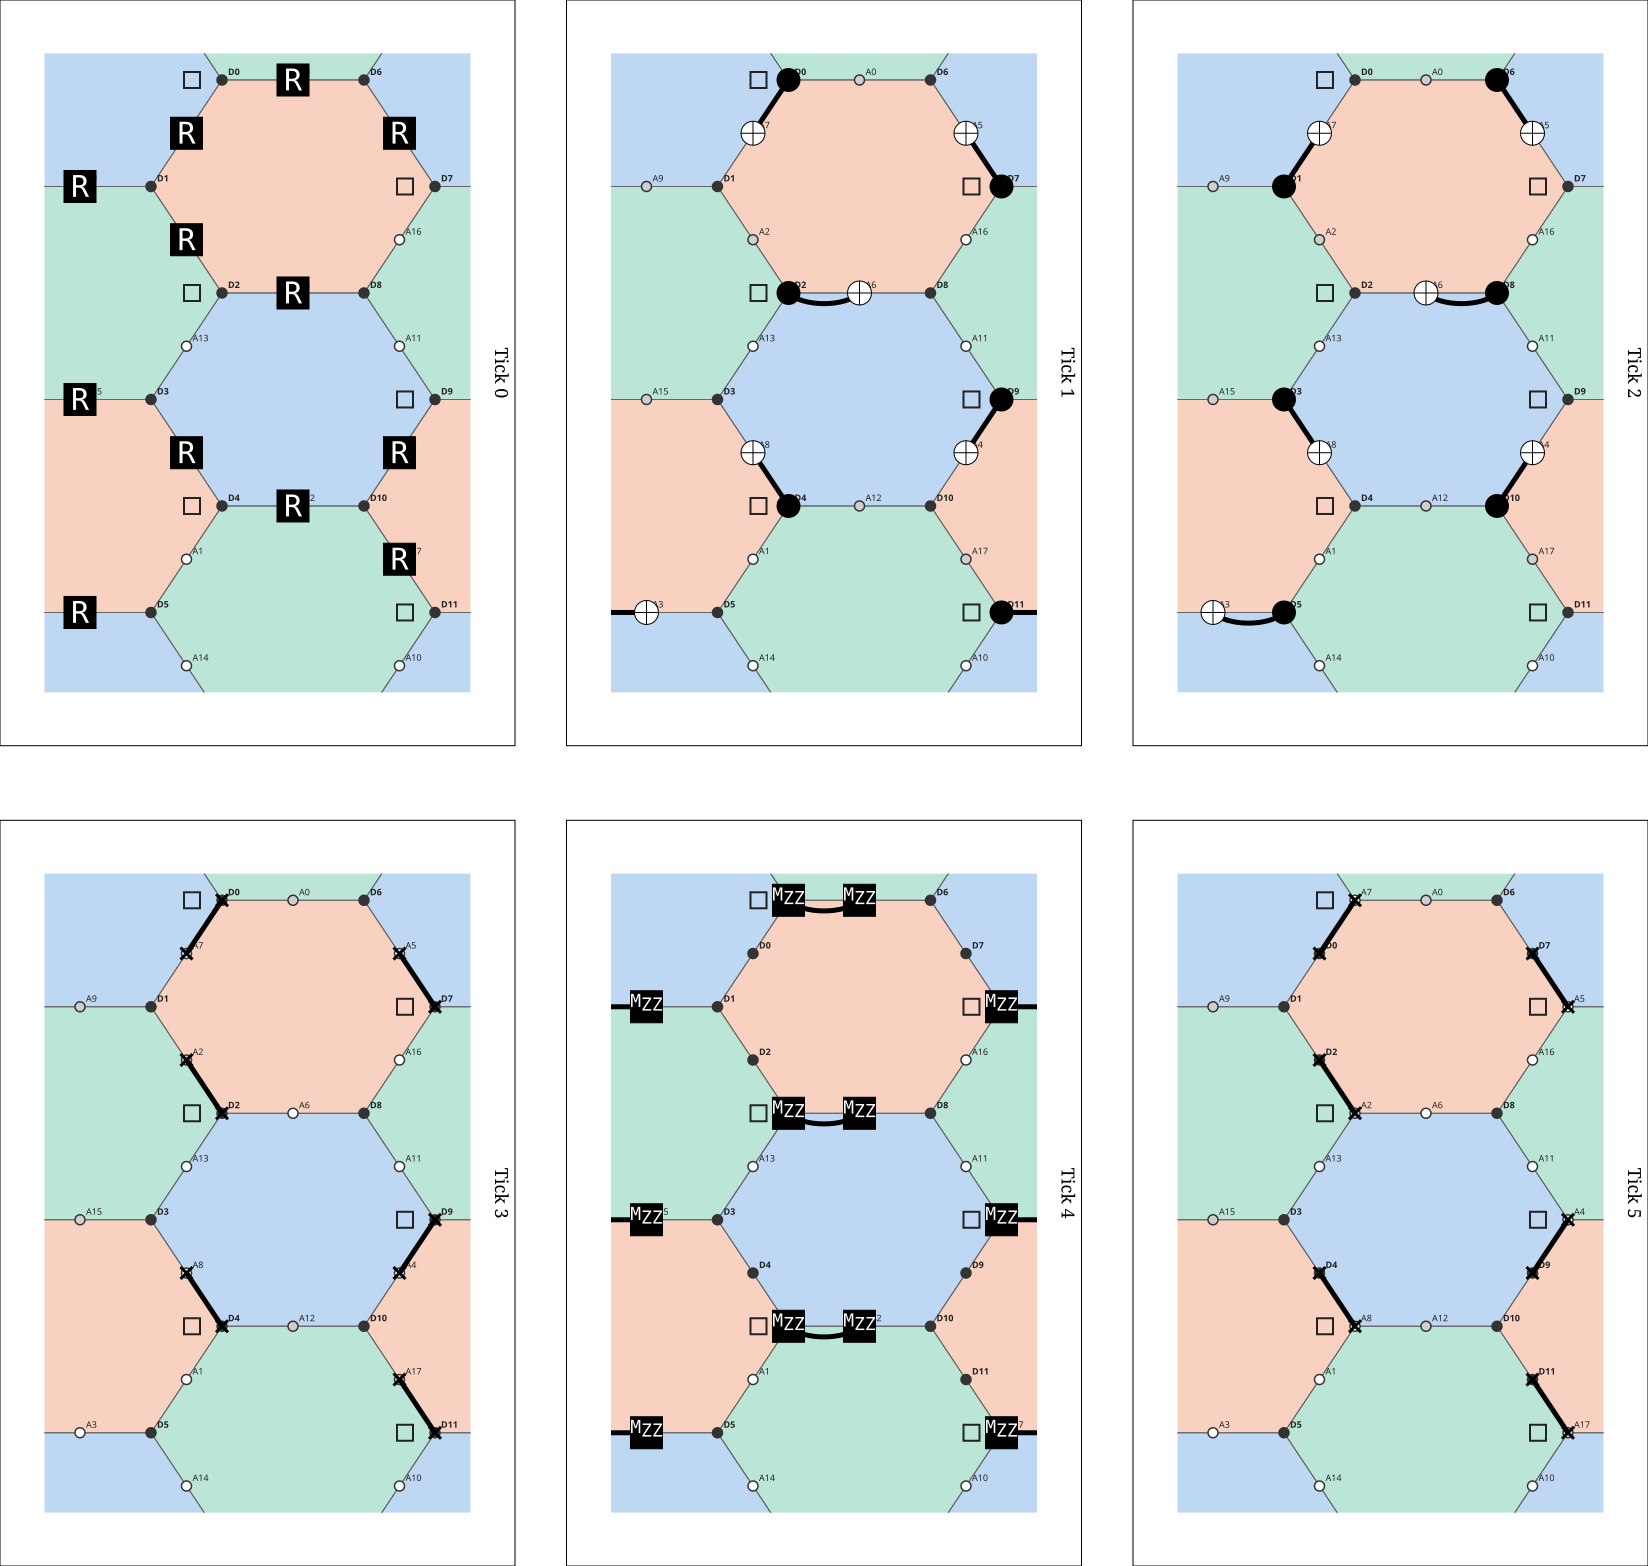

In [4]:
for r in range(6):
    print(f"step {r}: {'XZ'[r % 2] * 2} on {names[r % 3]} edges")
    display(SVG(shared.round_svg(DISTANCE, r, layers, hex_view=True, numbers=NUMBERS, away=AWAY)))

The same steps in brick-wall coordinates, which is what the circuits carry as QUBIT_COORDS.

step 0: XX on blue edges


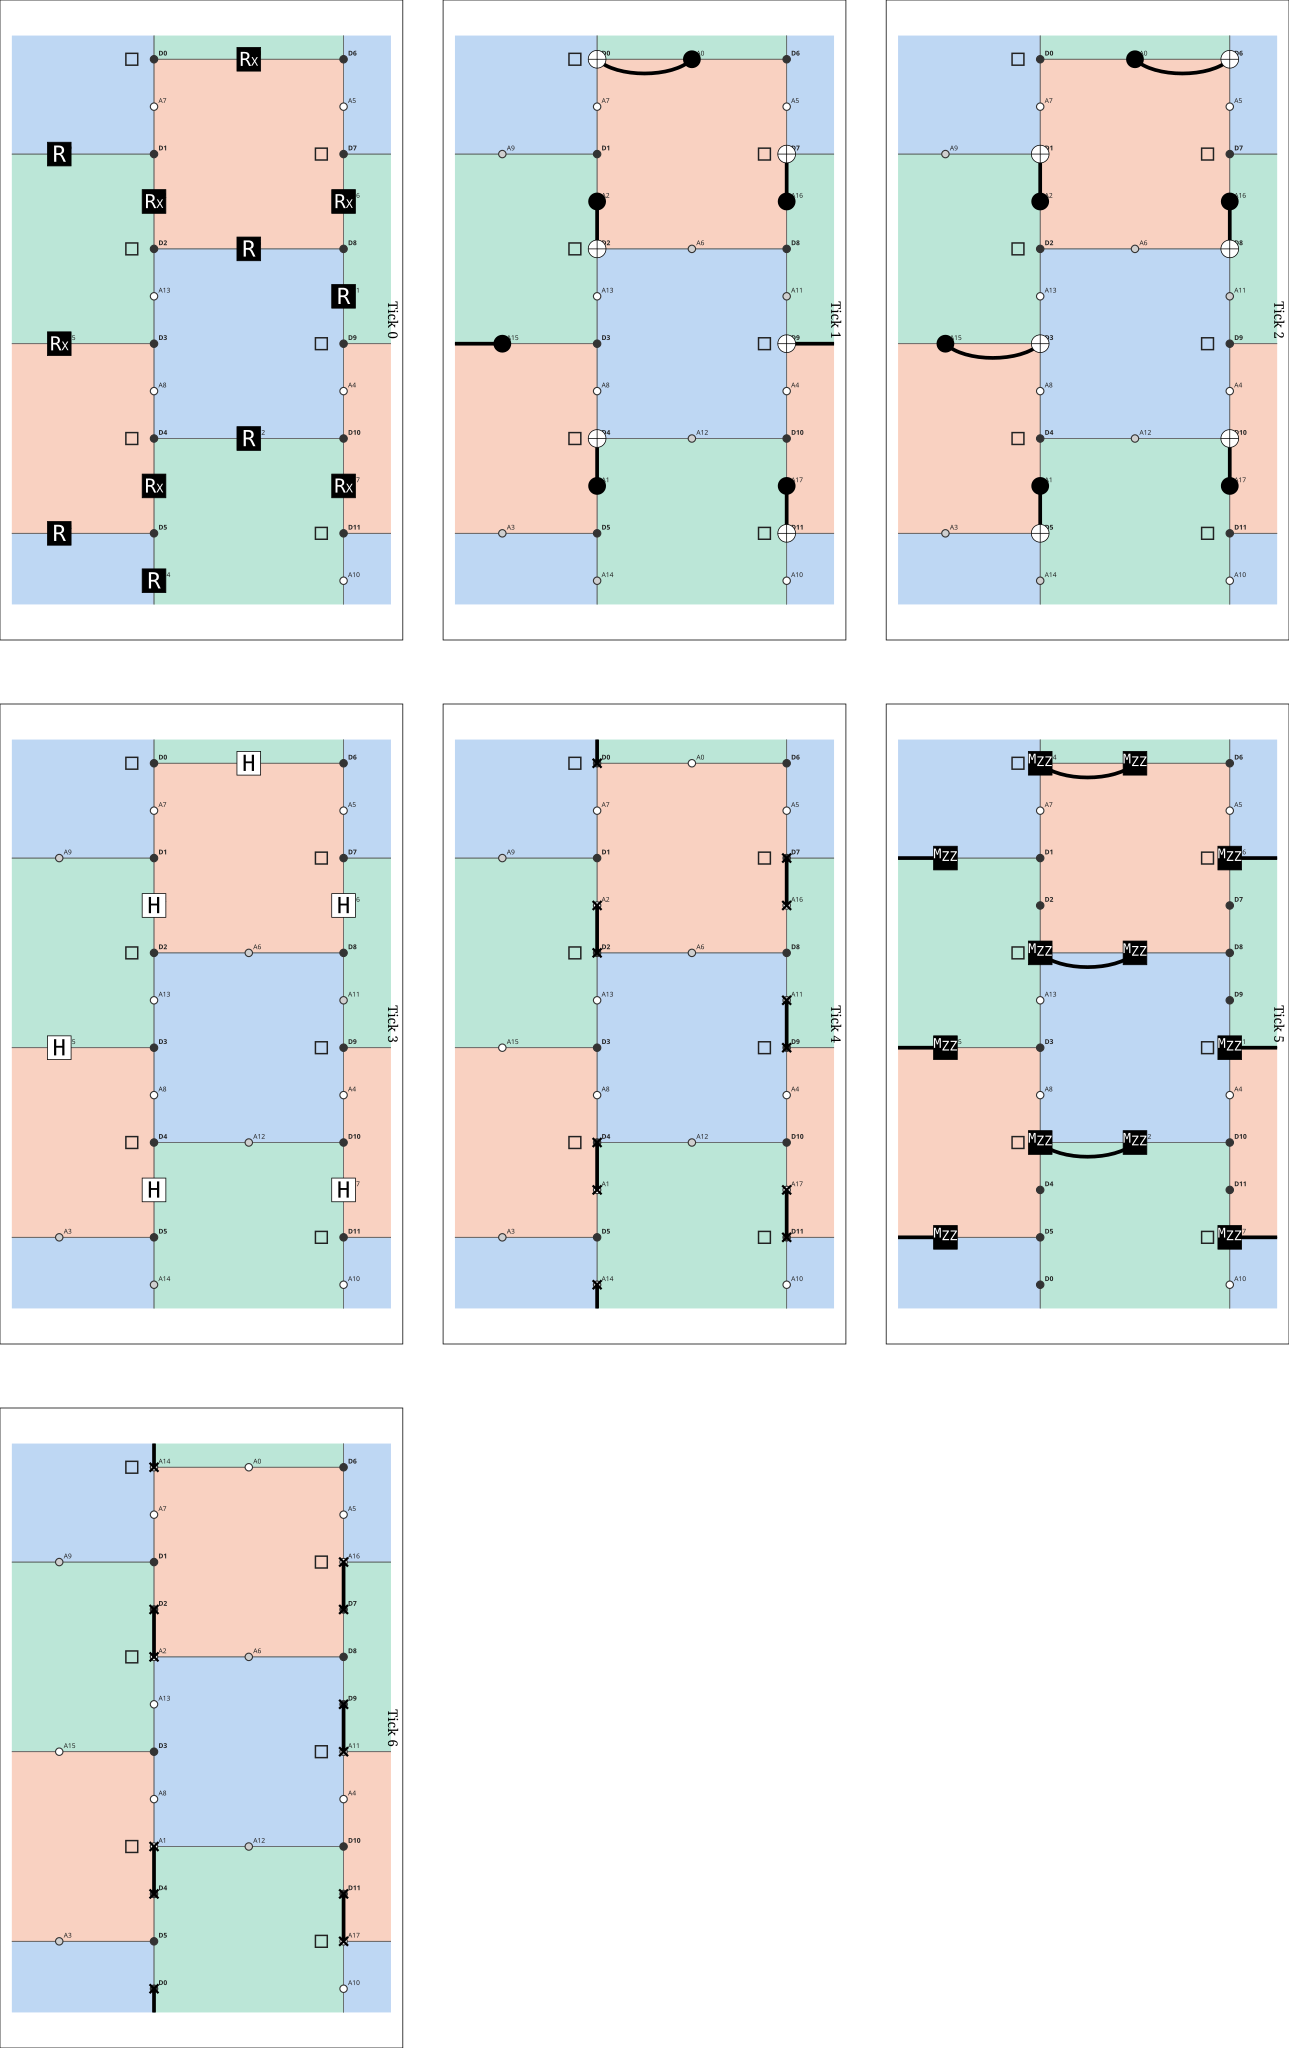

step 1: ZZ on red edges


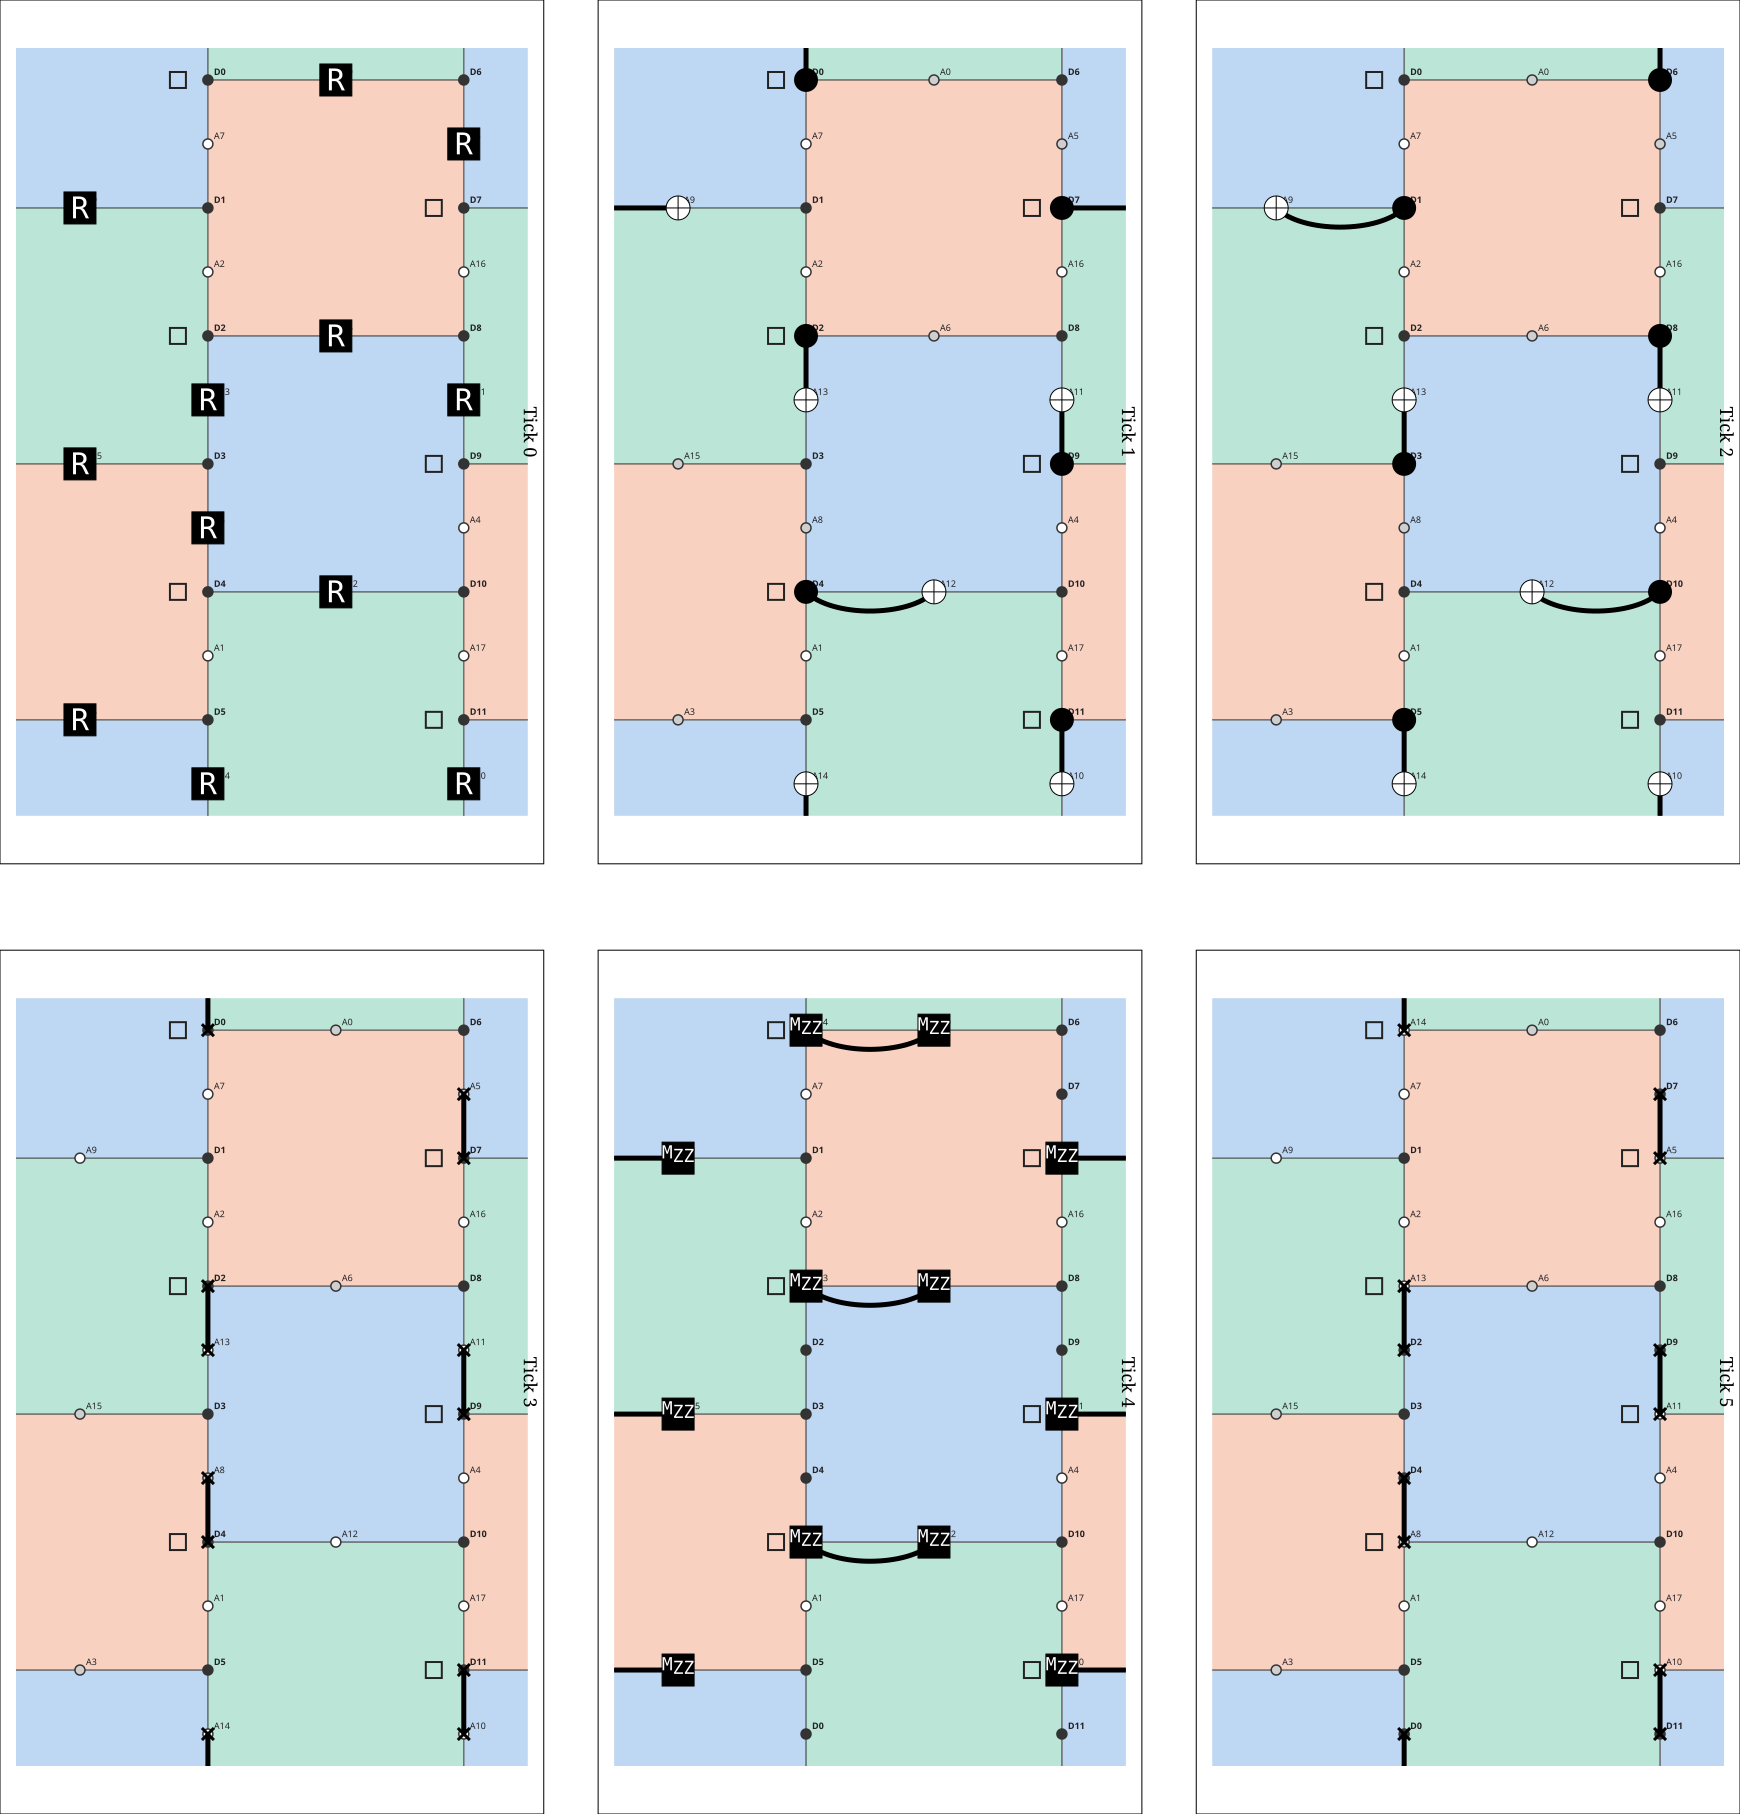

step 2: XX on green edges


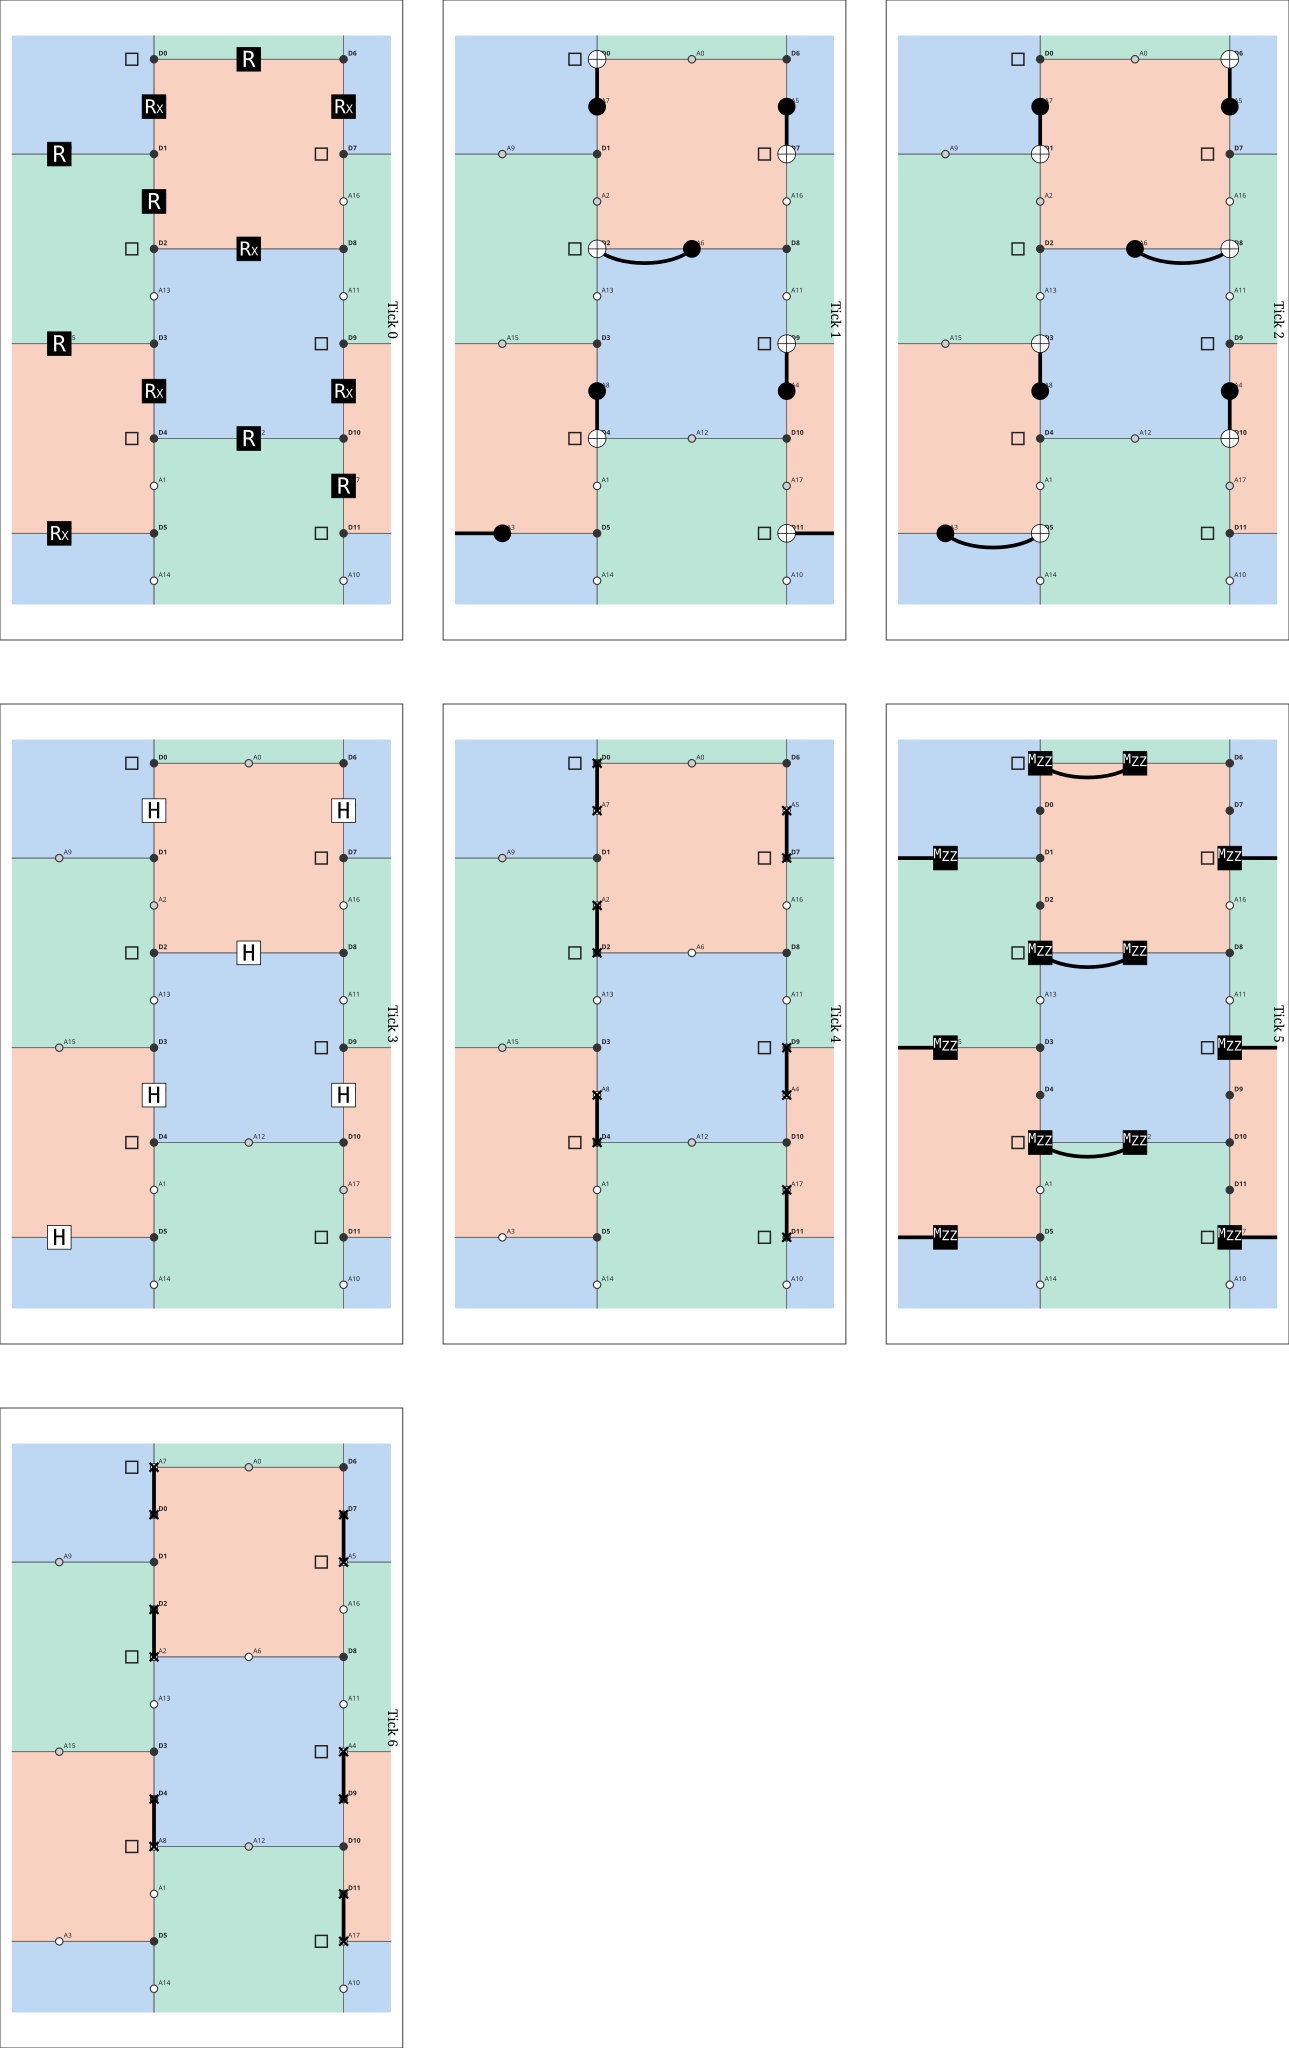

step 3: ZZ on blue edges


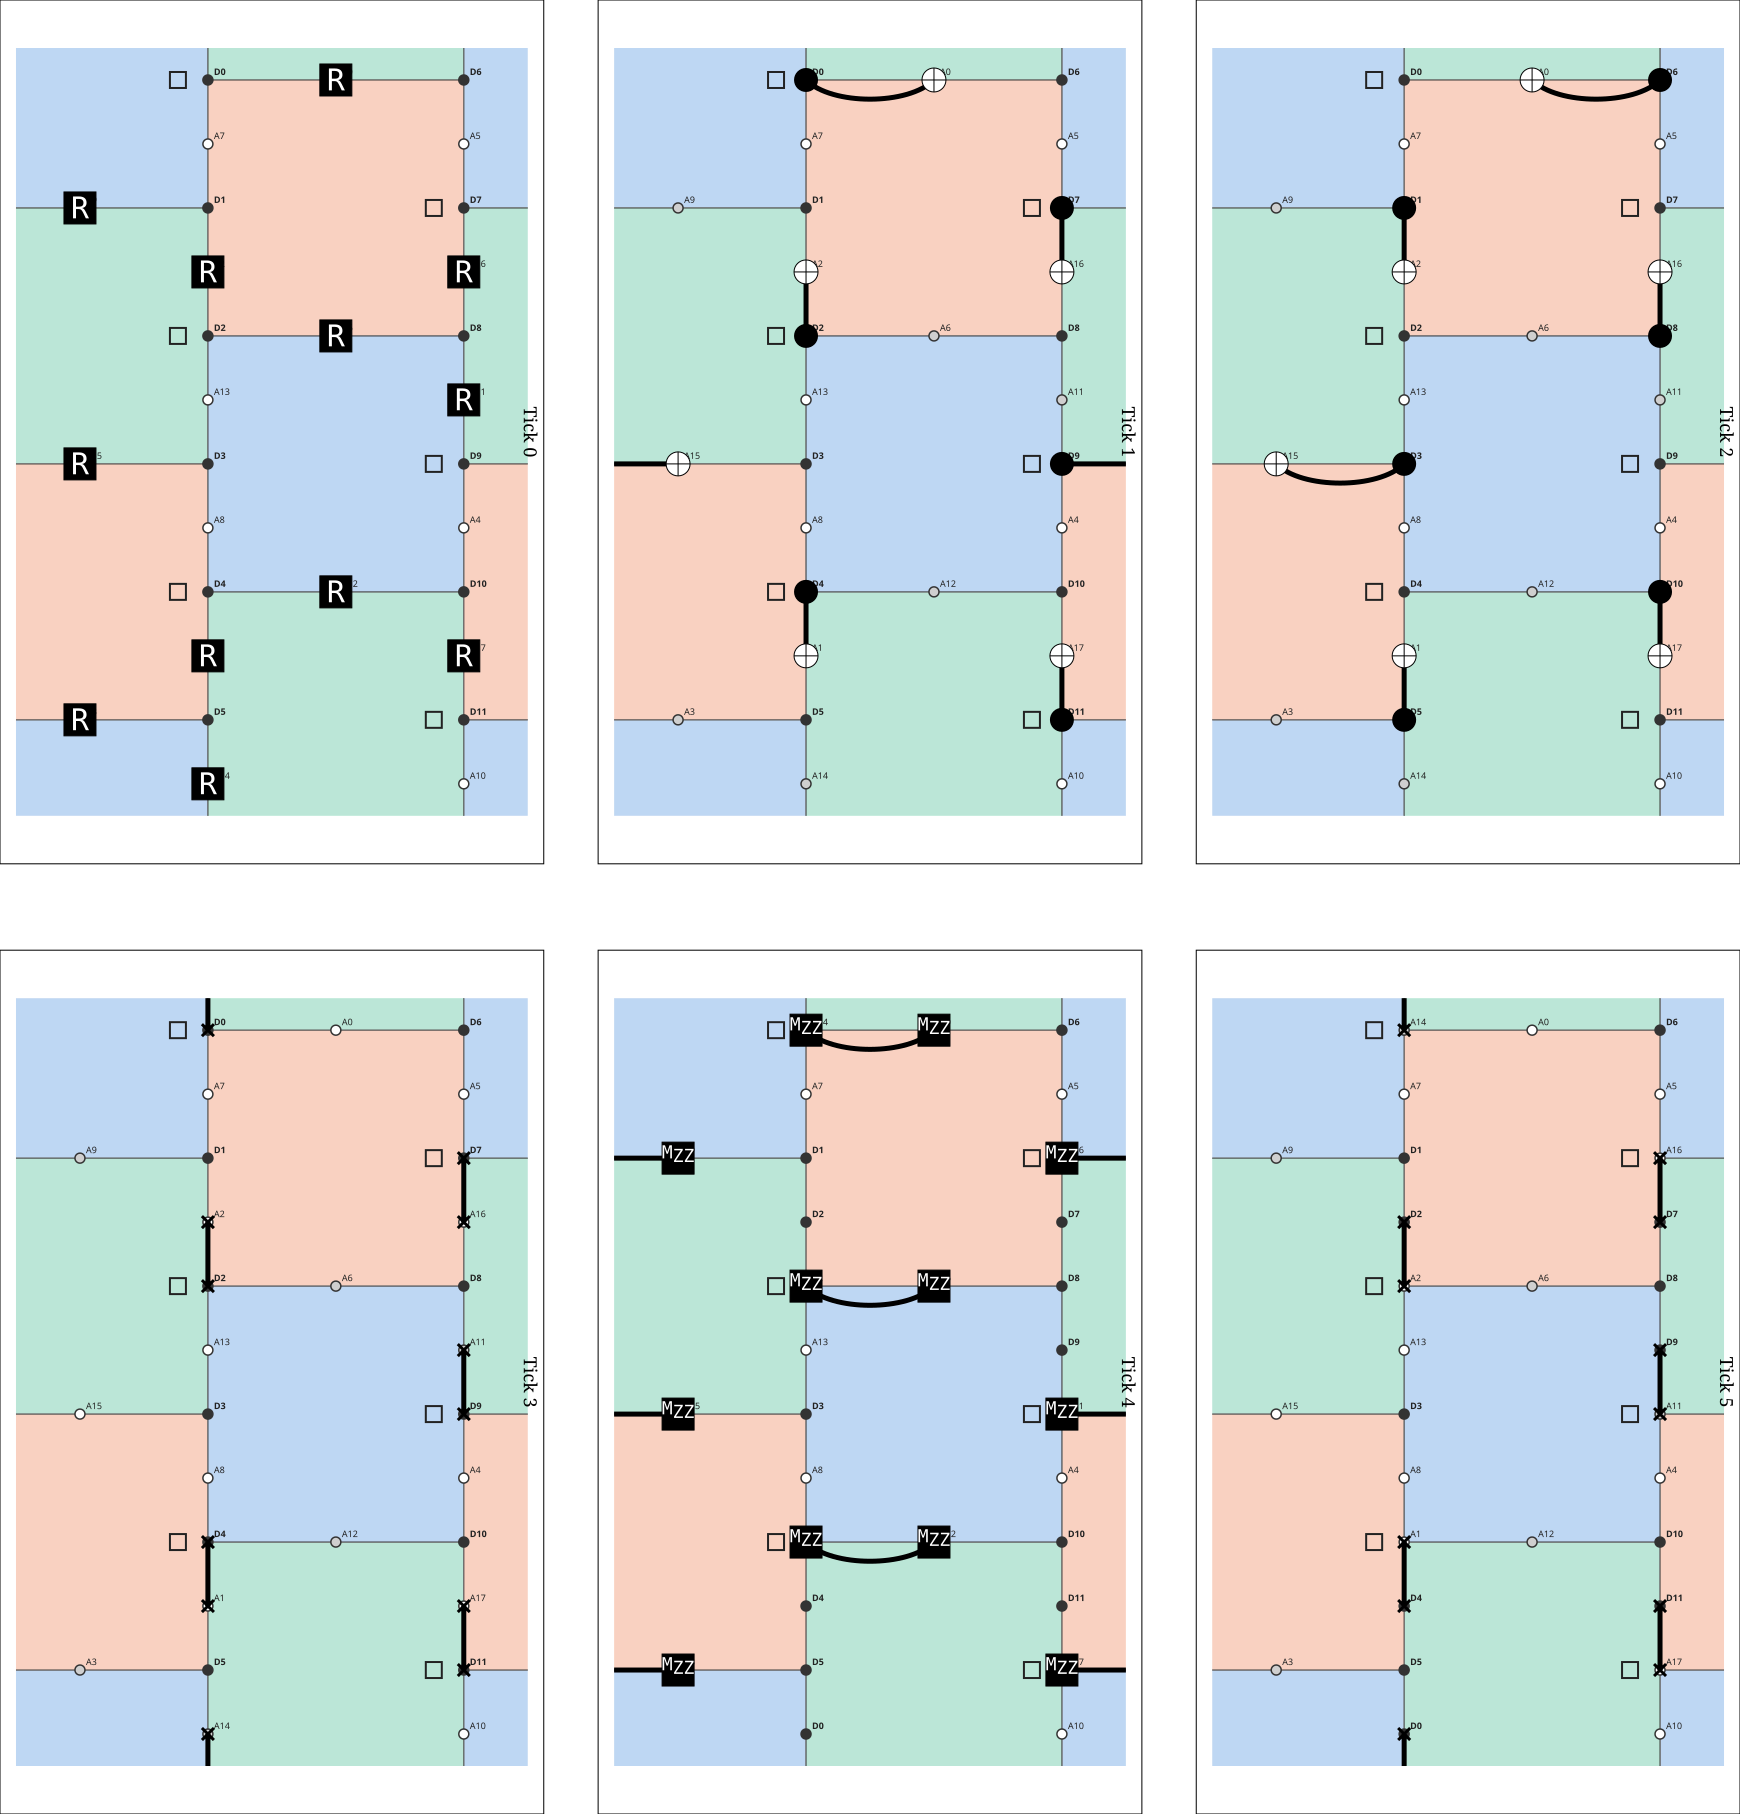

step 4: XX on red edges


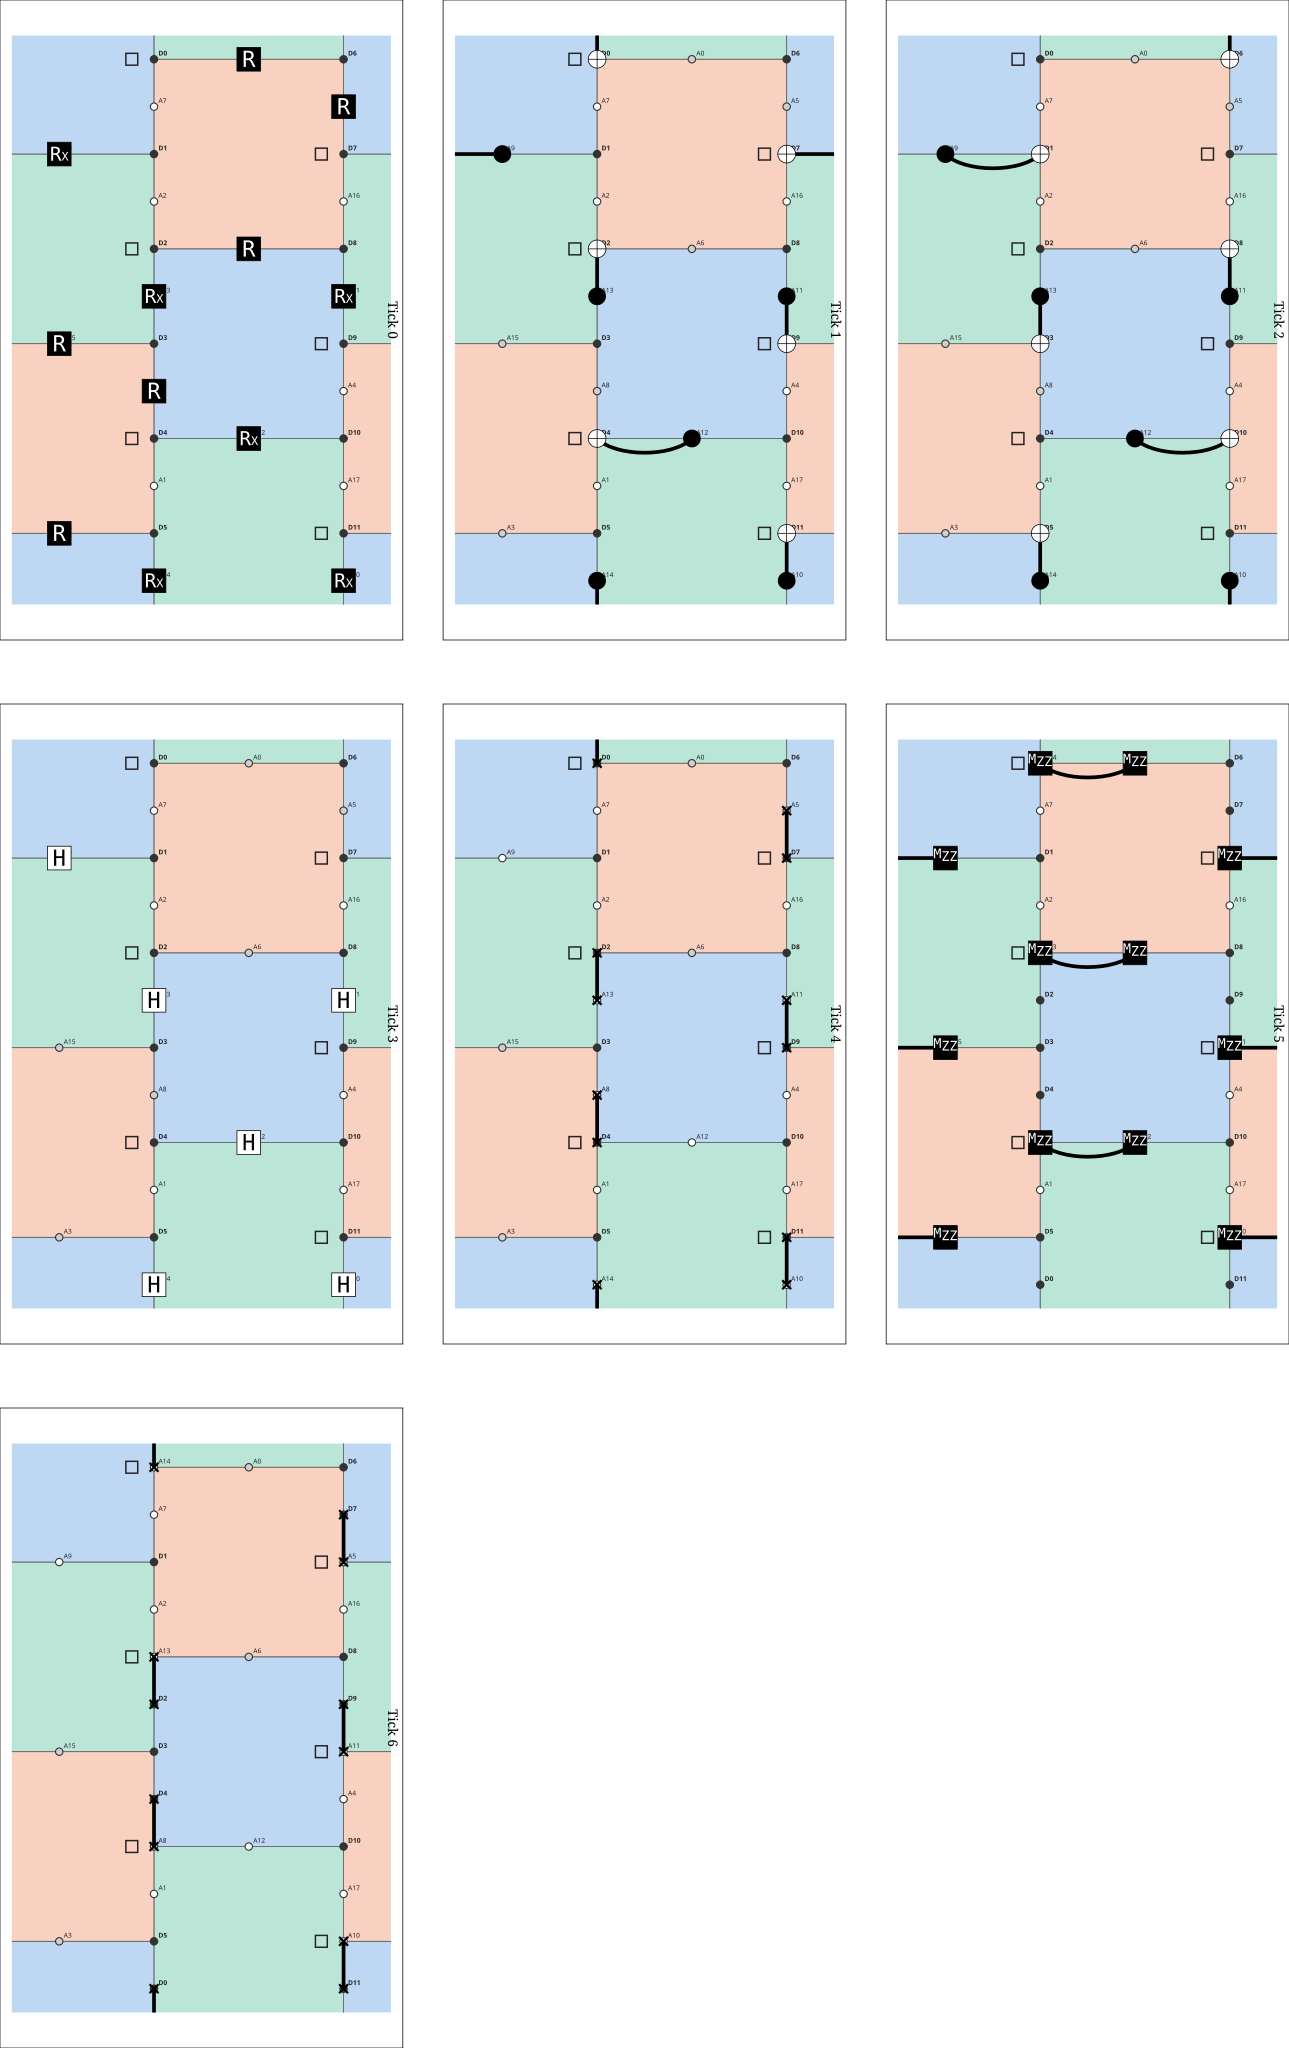

step 5: ZZ on green edges


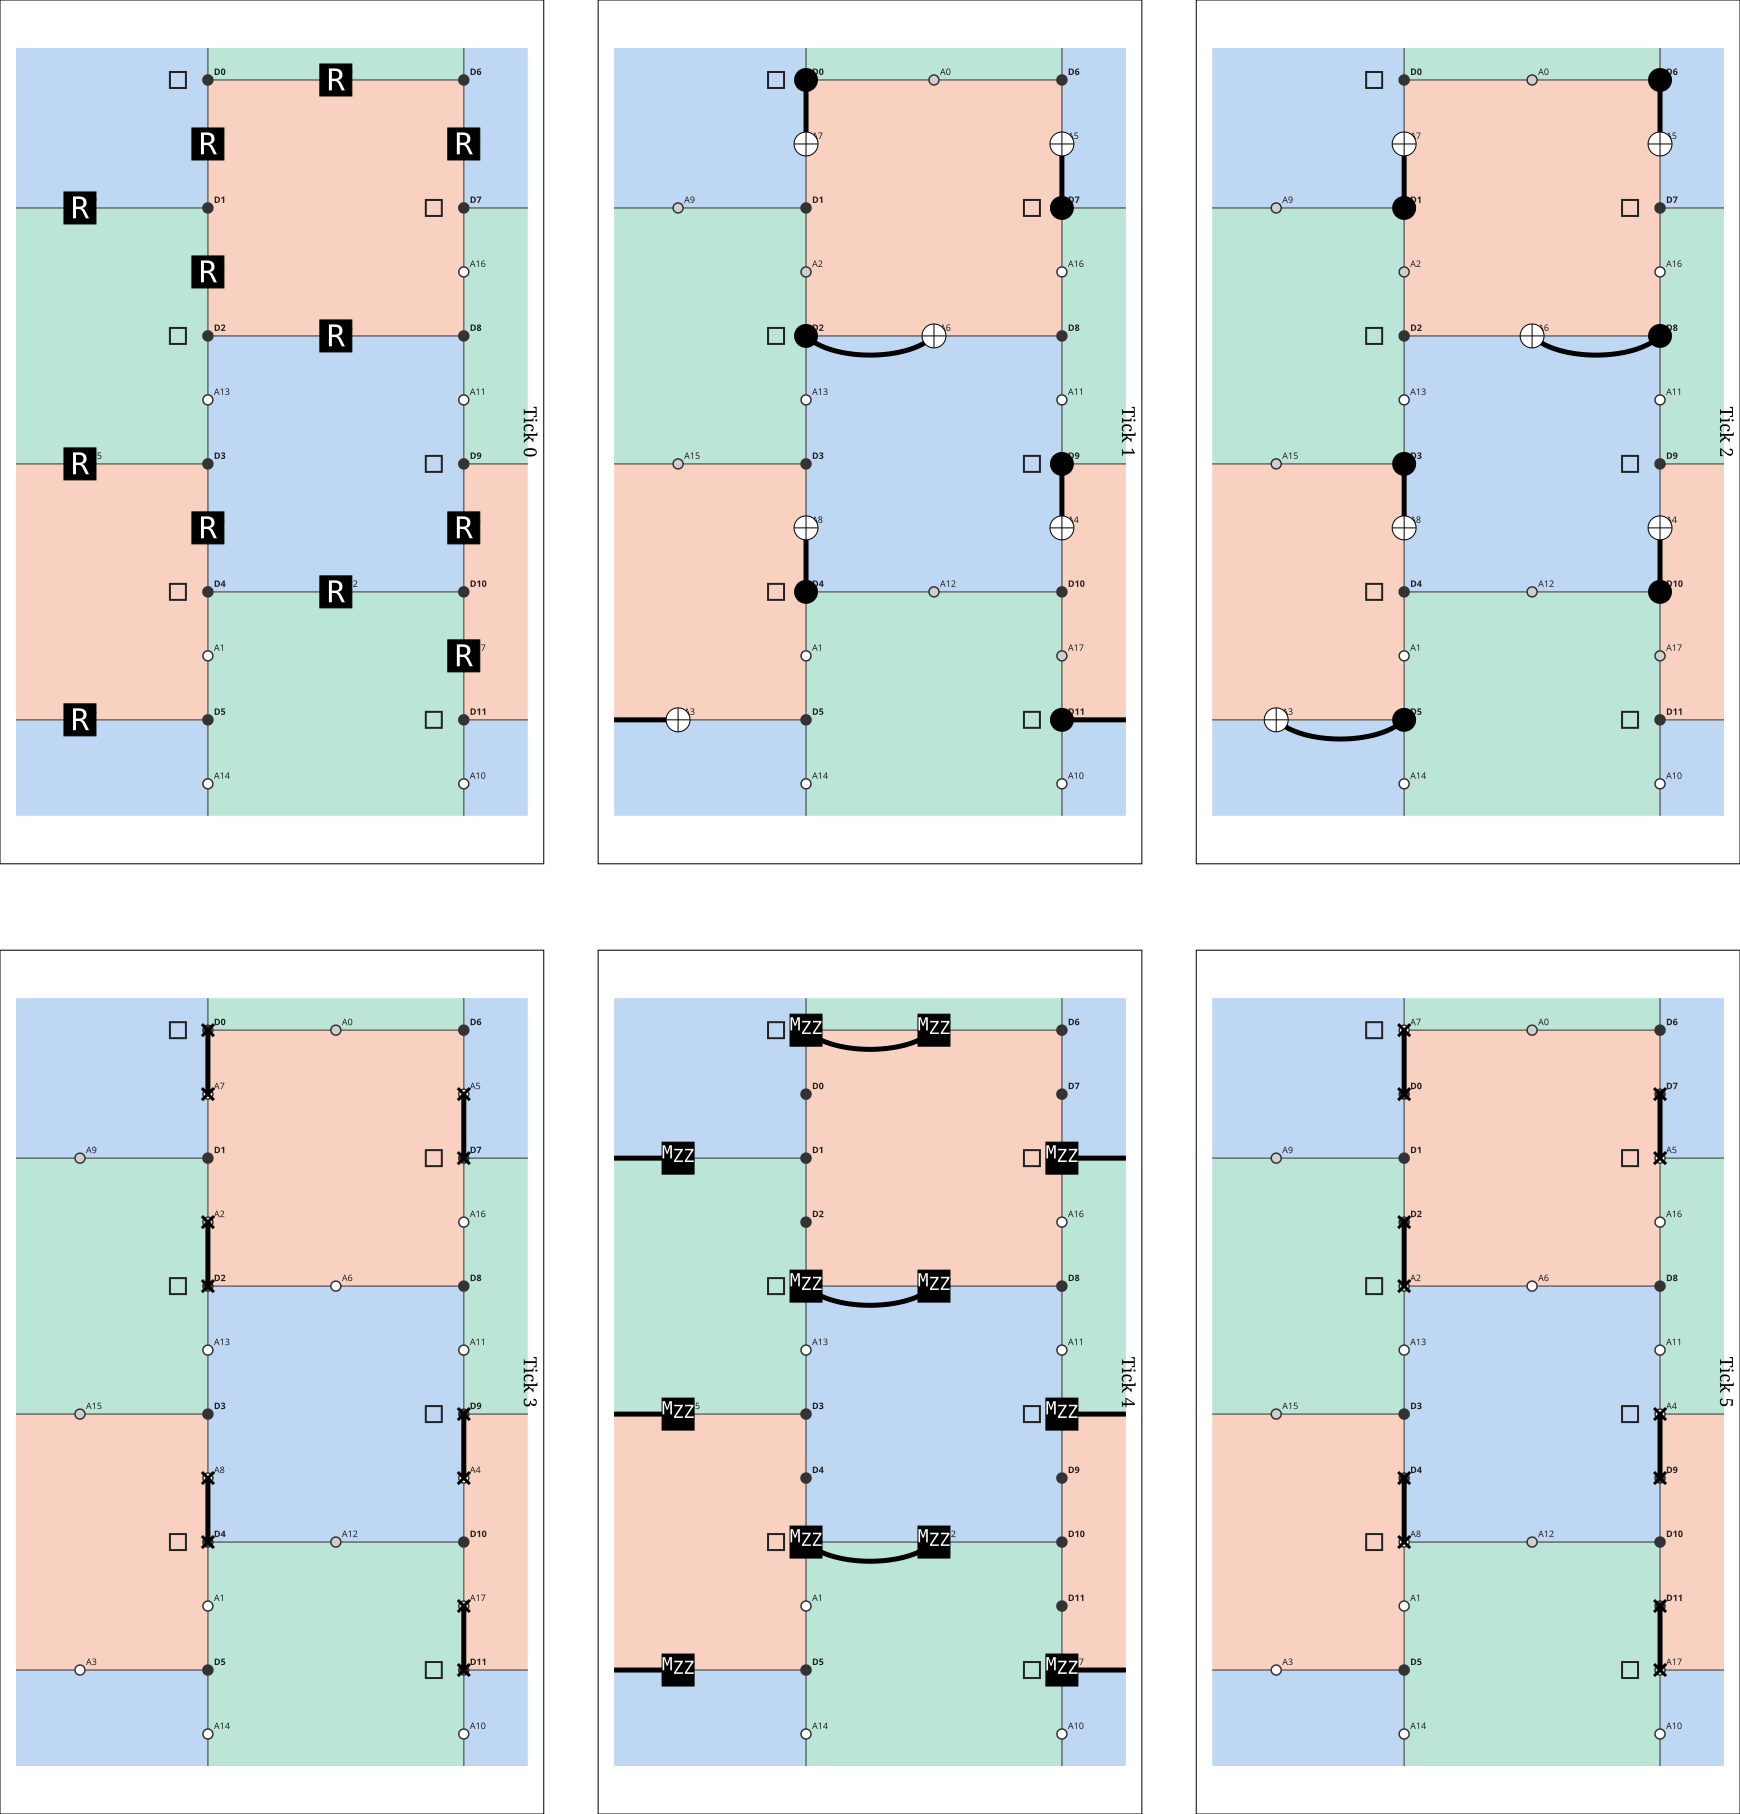

In [5]:
for r in range(6):
    print(f"step {r}: {'XZ'[r % 2] * 2} on {names[r % 3]} edges")
    display(SVG(shared.round_svg(DISTANCE, r, layers, hex_view=False, numbers=NUMBERS, away=AWAY)))

## One step as a circuit

The gates behind step 0, with the QUBIT_COORDS lines dropped: every check runs its layer at the same time.

In [6]:
circuit = shared.round_circuit(DISTANCE, 0, layers)
print(f"{circuit.num_qubits} qubits, {circuit.num_ticks} ticks, {circuit.num_measurements} measurements\n")
print("\n".join(line for line in str(circuit).splitlines() if not line.startswith("QUBIT_COORDS")))

30 qubits, 7 ticks, 6 measurements

RX 12
R 26
RX 13
R 24
RX 14
R 18
RX 27
R 23
RX 28
R 21
RX 29
R 15
TICK
CX 12 0 13 4 14 2 27 9 28 7 29 11
TICK
CX 12 6 13 5 14 1 27 3 28 8 29 10
TICK
H 12 13 14 27 28 29
TICK
SWAP 26 0 13 4 14 2 23 9 28 7 29 11
TICK
MZZ 12 0 4 24 2 18 27 9 7 21 11 15
TICK
SWAP 26 0 13 4 14 2 23 9 28 7 29 11
TICK


## Charge sensors

Every readout happens at some hex's right corner, one per hex. A sensor sits on the far side of the corner from
the qubit it is read against, so the number of sensors a corner needs is the number of directions its readout
partner comes from over the six steps.

In [7]:
right = {q2i[torus(h + 1, DISTANCE)] for h in hex_centers(DISTANCE)}
p = period(DISTANCE)
wrap = lambda z: complex((z.real + p.real / 2) % p.real - p.real / 2, (z.imag + p.imag / 2) % p.imag - p.imag / 2)
directions = {}
for r in range(6):
    circuit = shared.round_circuit(DISTANCE, r, layers, hex_view=True)
    xy = {i: complex(*c) for i, c in circuit.get_final_qubit_coordinates().items()}
    mzz = [t.value for inst in circuit if inst.name == "MZZ" for t in inst.targets_copy()]
    for i, j in zip(mzz[::2], mzz[1::2]):
        u, partner = (i, j) if i in right else (j, i)
        z = wrap(xy[partner] - xy[u])
        directions.setdefault(u, set()).add((round(z.real, 3), round(z.imag, 3)))
per_corner = {len(d) for d in directions.values()}
print(f"{len(hex_centers(DISTANCE))} hexes, {len(directions)} readout corners,"
      f" partner directions per corner: {per_corner}")
print(f"-> {sum(len(d) for d in directions.values())} sensor spots,"
      f" {sum(len(d) for d in directions.values()) / len(hex_centers(DISTANCE)):g} per hex")

6 hexes, 6 readout corners, partner directions per corner: {1}
-> 6 sensor spots, 1 per hex


## What is checked

`shared.check` asserts: each colour's checks cover every data qubit once with that colour's edges and never share
an ancilla; every two-qubit gate joins a qubit to an ancilla on an edge next to it; record j holds check j's
parity (a stim flow); every data qubit is back where it started; and the memory experiment's detectors are
deterministic with these steps. The script runs it before drawing anything.

In [8]:
shared.check(DISTANCE, layers)
print(f"d = {DISTANCE}: all steps check out")

d = 1: all steps check out


## Decoding

`floquet.memory_circuit` takes the step circuit as an argument, so this method runs through the same memory
experiment as the ancilla pairs and method A: same detectors, same observable, same decoder
(`memory.count_logical_errors`, see `docs/decoding.pdf`). Only the circuits, and so the noise, differ.
`src/single_ancilla/decode.py` (`make decode`) sweeps p; here is one point per scheme.

In [9]:
from decode import SCHEMES, dem_stats
from floquet import memory_circuit
from memory import count_logical_errors
from noise import NOISE_MODELS, add_noise

D, P, SHOTS = 3, 2e-3, 10_000
schemes = ["pairs", "method_a", "method_b"]
for name, s in dem_stats(D, "spin", 10.0, P, schemes).items():
    print(f"{name:12}", ", ".join(f"{k} {v}" for k, v in s.items()))
for name in schemes:
    noisy = add_noise(memory_circuit(D, D, SCHEMES[name]), NOISE_MODELS["spin"](P, 10.0))
    print(f"{name:12} d = {D}, p = {P:g}: LER {count_logical_errors(noisy, SHOTS) / SHOTS:.2e}")

pairs        qubits 432, ticks 100, detectors 360, mechanisms 4176, hyperedges 2430, distance 9
method_a     qubits 270, ticks 136, detectors 360, mechanisms 4176, hyperedges 2430, distance 9
method_b     qubits 270, ticks 118, detectors 360, mechanisms 4176, hyperedges 2430, distance 9
pairs        d = 3, p = 0.002: LER 4.70e-03
method_a     d = 3, p = 0.002: LER 8.90e-03
method_b     d = 3, p = 0.002: LER 7.00e-03
